## FRAP analyses - interpretation

___

In [21]:
from pathlib import Path
from microlive.pipelines.pipeline_FRAP import *
from microlive.imports import *
from microlive import microscopy as mi
current_dir = Path().resolve()
import scipy.stats as stats
from scipy.stats import ttest_ind
from itertools import combinations
from statsmodels.stats.multitest import multipletests
one_drive_dir = mi.Utilities.get_one_drive_dir()

# Import plotting functions from module
from frap_plotting_module import (
    plot_FRAP_trajectories,
    plot_mean_trajectories_all,
    plot_box_swarm_final_values,
    plot_box_swarm_fit_results,
)

In [22]:
#results_main_folder = one_drive_dir.joinpath('General - Zhao (NZ) Lab/Microscope/Rhiannon (microscope)/LaG16 Binding Stiochiometry/results_rs')
#results_main_folder = one_drive_dir.joinpath('General - Zhao (NZ) Lab/Our papers/co-translational folding paper/OLD_Fig 1/Fig 1_FRAP/FRAP_analyses_20250929')
results_main_folder = dataframes_dir = Path('E:/Co-translational folding (CoF) paper/FRAP_analyses_20250929')
cwd = Path.cwd()
results_main_folder = results_main_folder.joinpath('results')
process_single_days = False  # Set to False to combine datasets from multiple days

In [23]:
results_main_folder

WindowsPath('E:/Co-translational folding (CoF) paper/FRAP_analyses_20250929/results')

In [24]:
#results_main_folder = Path(r'C:\Users\searsrh\OneDrive - The University of Colorado Denver\General - Zhao (NZ) Lab\Zhao lab shared folder\Our papers\co-translational folding paper\OLD_Fig 1\Fig 1_FRAP\FRAP_analyses_20250929\results')

In [25]:
# List all immediate subfolders in results_main_folder
subfolders = [folder for folder in results_main_folder.iterdir() if folder.is_dir()]

if process_single_days:
    subfolder_strings = {'sf_d1' :  ["20250709 pRS046", "None"] ,
                        'sf_d2' :  ["20250820 pRS046", "None"] ,
                        'uv_d1': ["20250820 pRS056", "None"],
                        'uv_d2': ["20250828 pRS056", "None"]} 
    list_datasets  = ['sf_d1','sf_d2','uv_d1','uv_d2']
    datasets_to_process = ['sf_d1', 'sf_d2', 'uv_d1', 'uv_d2']
else:
    subfolder_strings = {'sf' :  ["pRS046", "None"] ,
                        'uv': ["pRS056", "None"]} 
    list_datasets  = ['sf','uv']
    datasets_to_process = ['sf', 'uv']


In [26]:
frap_time = 10 # seconds

In [27]:
results_folder = results_main_folder.joinpath('results_20260602') 
results_folder.mkdir(exist_ok=True)

# Min–Max Normalization

We apply the following equation to normalize the values in the `mean_roi_frap_normalized` column:

$\text{normalized\_value} = \frac{\text{value} - \text{min\_val}}{\text{max\_val} - \text{min\_val}}$

In [28]:
apply_quality_check = True
drop_threshold = 0.4
apply_min_max_normalization = True  # Set to False to skip normalization

# Define your dataset types and initialize lists

list_df_paths = []
list_df_FRAP = []
total_number_cells = 0
selected_field = 'mean_roi_frap' # mean_roi_frap_normalized
# Iterate over each dataset type
for dataset_type in list_datasets:
    # Loop through each subfolder (assumes 'subfolders' is defined)
    for subfolder in subfolders:
        # Check if the subfolder name matches one of the strings for this dataset type
        if (subfolder_strings[dataset_type][0] in subfolder.stem) or (subfolder_strings[dataset_type][1] in subfolder.stem):
            # Get CSV files that don't contain the unwanted substrings
            csv_files = [f for f in subfolder.glob("*.csv") 
                         if "no_roi_detected" not in f.name and "df_FRAP_fit" not in f.name]
            if csv_files:
                # Use the first matching CSV file (you may modify this logic if needed)
                selected_csv_path = csv_files[0]
                selected_df = pd.read_csv(selected_csv_path)
                # Keep only the necessary columns
                selected_df_copy = selected_df[['frame', selected_field, 'image_name']].copy()
                
                # Add new columns: dataset_type and subfolder_id
                selected_df_copy['dataset_type'] = dataset_type
                selected_df_copy['subfolder_id'] = subfolder.stem
                
                # Create a unique cell_id for each unique image (cell)
                unique_cells = selected_df_copy['image_name'].unique()
                cell_id_map = {cell: f"{subfolder.stem}_{i}" for i, cell in enumerate(unique_cells, start=1)}
                selected_df_copy['cell_id'] = selected_df_copy['image_name'].map(cell_id_map)
                
                # If quality check is enabled, filter cells based on drop threshold (using unnormalized data)
                if apply_quality_check:
                    filtered_df = pd.DataFrame()
                    for cell in selected_df_copy['image_name'].unique():
                        cell_data = selected_df_copy[selected_df_copy['image_name'] == cell]
                        # Extract data for the first 20 seconds
                        subset_data = cell_data[cell_data['frame'] <= 20]
                        if subset_data.empty:
                            
                            continue
                        initial_intensity = subset_data[selected_field].iloc[0]
                        min_intensity = subset_data[selected_field].min()
                        drop = initial_intensity - min_intensity
                        # Only keep cells with a drop greater than the threshold
                        if drop > drop_threshold:
                            filtered_df = pd.concat([filtered_df, cell_data], ignore_index=True)
                        else:
                            print(f"Cell {cell} in {subfolder.stem} dropped due to insufficient drop ({drop:.2f})")
                    selected_df_copy = filtered_df.copy()
                
                # Optionally apply min–max normalization per cell (after quality check)
                if apply_min_max_normalization:
                    normalized_list = []
                    for cell in selected_df_copy['image_name'].unique():
                        cell_data = selected_df_copy[selected_df_copy['image_name'] == cell].copy()
                        min_val = cell_data[selected_field].min()
                        max_val = cell_data[selected_field].max()
                        if max_val > min_val:
                            cell_data[selected_field] = (
                                cell_data[selected_field] - min_val
                            ) / (max_val - min_val)
                        else:
                            cell_data[selected_field] = 0.0
                        normalized_list.append(cell_data)
                    selected_df_copy = pd.concat(normalized_list, ignore_index=True)
                
                # Append the selected data if not empty
                if not selected_df_copy.empty:
                    list_df_paths.append(selected_csv_path)
                    list_df_FRAP.append(selected_df_copy)
                    total_number_cells += selected_df_copy['cell_id'].nunique()

# Combine all extracted DataFrames into a single dataset
combined_df = pd.concat(list_df_FRAP, ignore_index=True)

# (Optional) Print out the total number of processed rows/cells
print("Combined DataFrame shape:", combined_df.shape)
print("Total number of processed cells:", total_number_cells)

Combined DataFrame shape: (19220, 6)
Total number of processed cells: 62


In [29]:
combined_df

,frame,mean_roi_frap,image_name,dataset_type,subfolder_id,cell_id
0,0.0,0.980523,FRAP 005,sf,results_FRAP_20250709 pRS046_050 FRAP,results_FRAP_20250709 pRS046_050 FRAP_1
1,1.0,0.979137,FRAP 005,sf,results_FRAP_20250709 pRS046_050 FRAP,results_FRAP_20250709 pRS046_050 FRAP_1
2,2.0,0.983593,FRAP 005,sf,results_FRAP_20250709 pRS046_050 FRAP,results_FRAP_20250709 pRS046_050 FRAP_1
3,3.0,0.974260,FRAP 005,sf,results_FRAP_20250709 pRS046_050 FRAP,results_FRAP_20250709 pRS046_050 FRAP_1
4,4.0,1.000000,FRAP 005,sf,results_FRAP_20250709 pRS046_050 FRAP,results_FRAP_20250709 pRS046_050 FRAP_1
...,...,...,...,...,...,...
19215,600.0,0.998193,FRAP 020,uv,results_FRAP_20250828 pRS056_050 FRAP,results_FRAP_20250828 pRS056_050 FRAP_19
19216,602.0,0.995786,FRAP 020,uv,results_FRAP_20250828 pRS056_050 FRAP,results_FRAP_20250828 pRS056_050 FRAP_19
19217,604.0,0.988473,FRAP 020,uv,results_FRAP_20250828 pRS056_050 FRAP,results_FRAP_20250828 pRS056_050 FRAP_19
19218,606.0,0.979971,FRAP 020,uv,results_FRAP_20250828 pRS056_050 FRAP,results_FRAP_20250828 pRS056_050 FRAP_19



Processing dataset: sf
Found 30 unique cells in 'sf' dataset
Processing cell: results_FRAP_20250709 pRS046_050 FRAP_1 (subfolder: results_FRAP_20250709 pRS046_050 FRAP, image: FRAP 005) with 310 frames


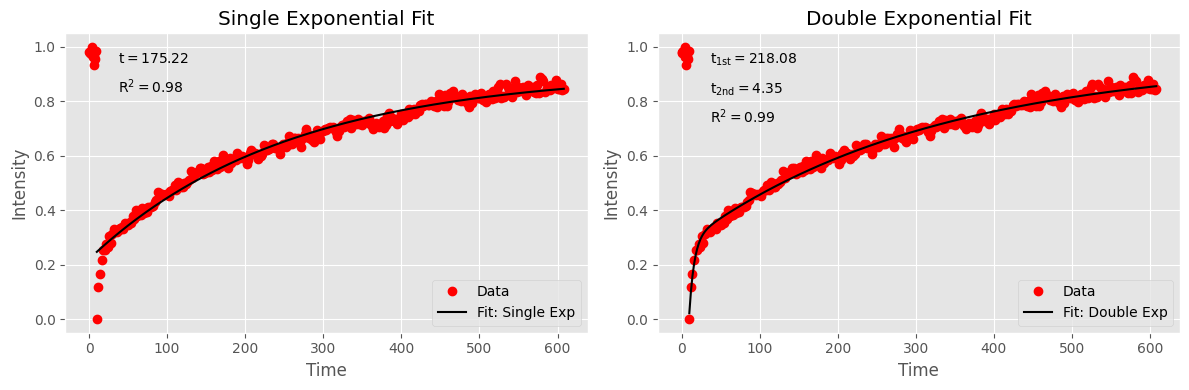

  Results - Single exp t½: 175.22, R²: 0.976
           Double exp t½1: 218.08, t½2: 4.35, R²: 0.989
--------------------------------------------------
Processing cell: results_FRAP_20250709 pRS046_050 FRAP_2 (subfolder: results_FRAP_20250709 pRS046_050 FRAP, image: FRAP 007) with 310 frames


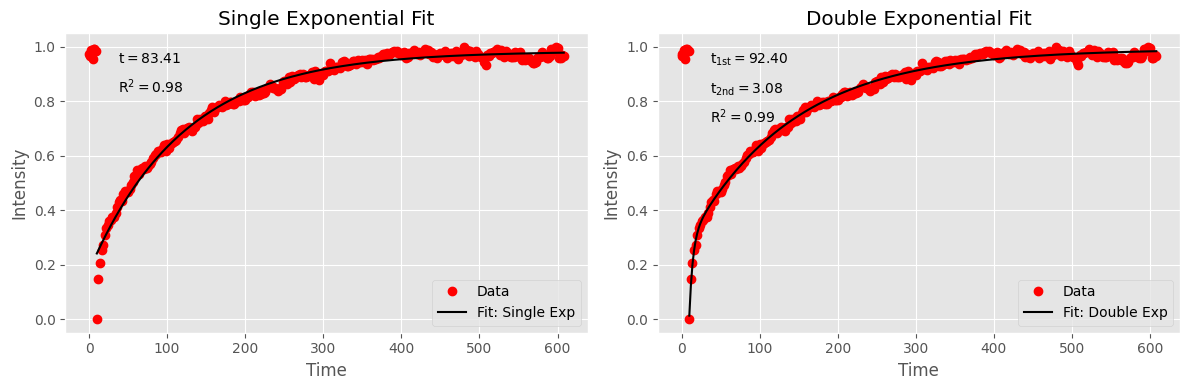

  Results - Single exp t½: 83.41, R²: 0.985
           Double exp t½1: 92.40, t½2: 3.08, R²: 0.994
--------------------------------------------------
Processing cell: results_FRAP_20250709 pRS046_050 FRAP_3 (subfolder: results_FRAP_20250709 pRS046_050 FRAP, image: FRAP 009) with 310 frames


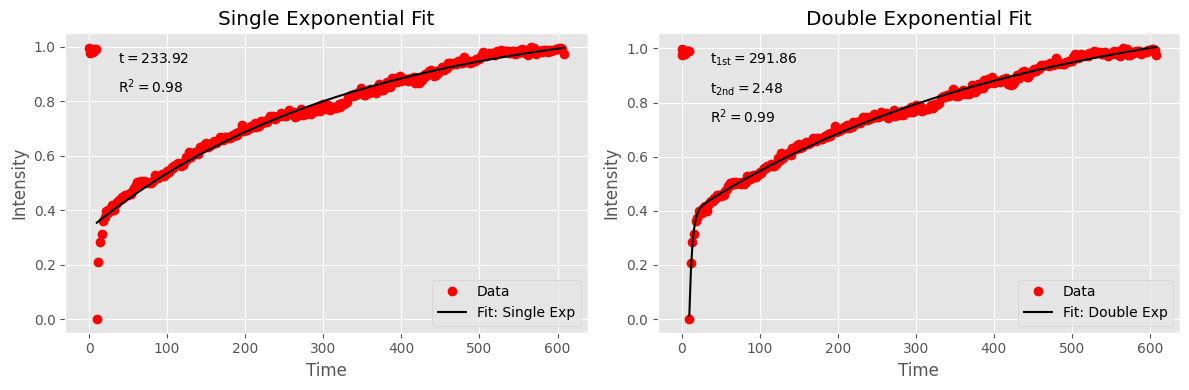

  Results - Single exp t½: 233.92, R²: 0.977
           Double exp t½1: 291.86, t½2: 2.48, R²: 0.994
--------------------------------------------------
Processing cell: results_FRAP_20250709 pRS046_050 FRAP_4 (subfolder: results_FRAP_20250709 pRS046_050 FRAP, image: FRAP 011) with 310 frames


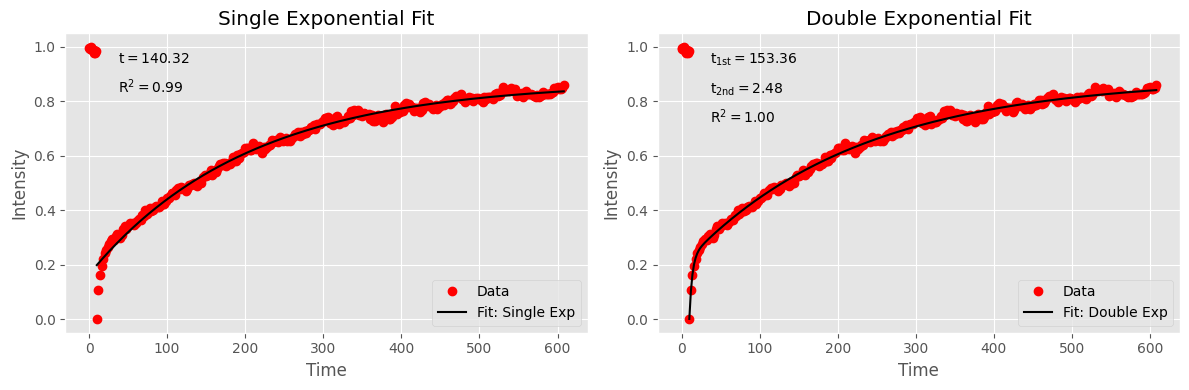

  Results - Single exp t½: 140.32, R²: 0.989
           Double exp t½1: 153.36, t½2: 2.48, R²: 0.995
--------------------------------------------------
Processing cell: results_FRAP_20250709 pRS046_050 FRAP_5 (subfolder: results_FRAP_20250709 pRS046_050 FRAP, image: FRAP 012) with 310 frames


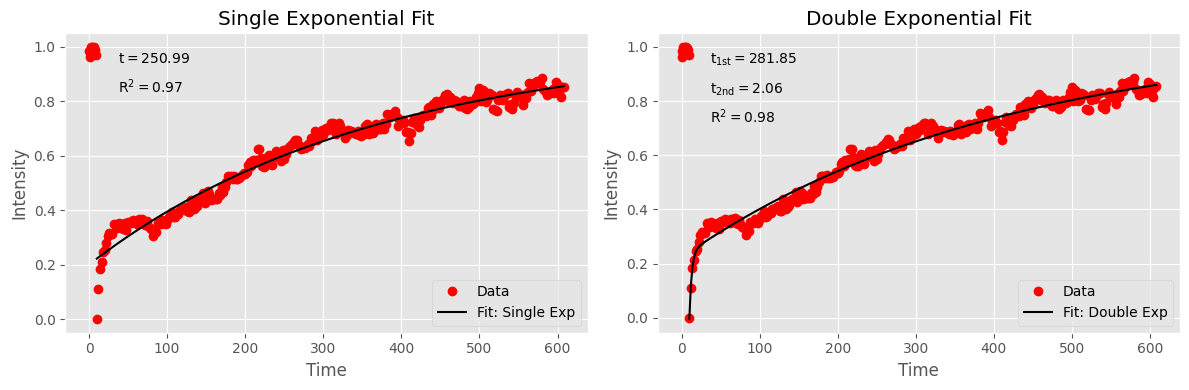

  Results - Single exp t½: 250.99, R²: 0.968
           Double exp t½1: 281.85, t½2: 2.06, R²: 0.976
--------------------------------------------------
Processing cell: results_FRAP_20250709 pRS046_050 FRAP_6 (subfolder: results_FRAP_20250709 pRS046_050 FRAP, image: FRAP 013) with 310 frames


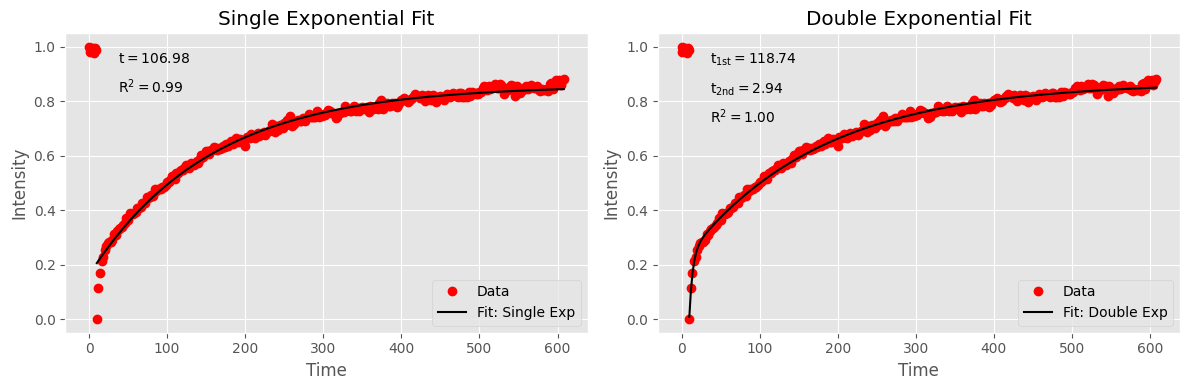

  Results - Single exp t½: 106.98, R²: 0.988
           Double exp t½1: 118.74, t½2: 2.94, R²: 0.996
--------------------------------------------------
Processing cell: results_FRAP_20250709 pRS046_050 FRAP_7 (subfolder: results_FRAP_20250709 pRS046_050 FRAP, image: FRAP 016) with 310 frames


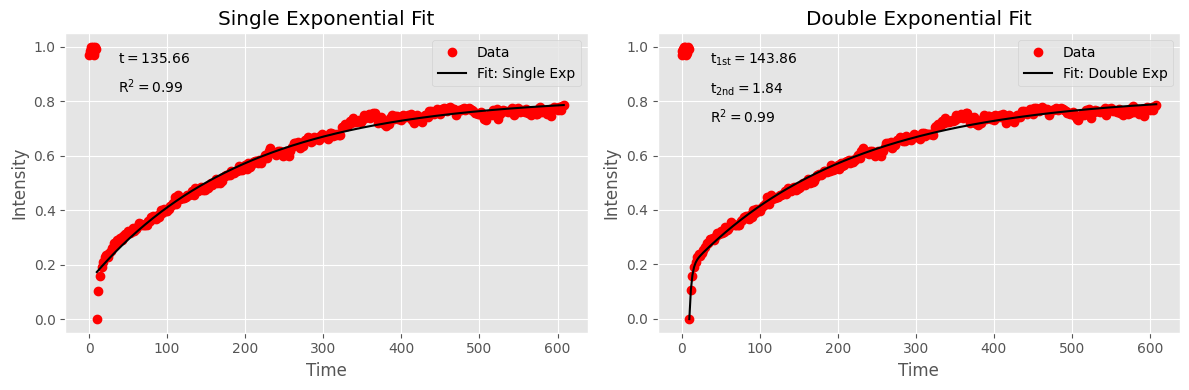

  Results - Single exp t½: 135.66, R²: 0.985
           Double exp t½1: 143.86, t½2: 1.84, R²: 0.990
--------------------------------------------------
Processing cell: results_FRAP_20250709 pRS046_050 FRAP_8 (subfolder: results_FRAP_20250709 pRS046_050 FRAP, image: FRAP 017) with 310 frames


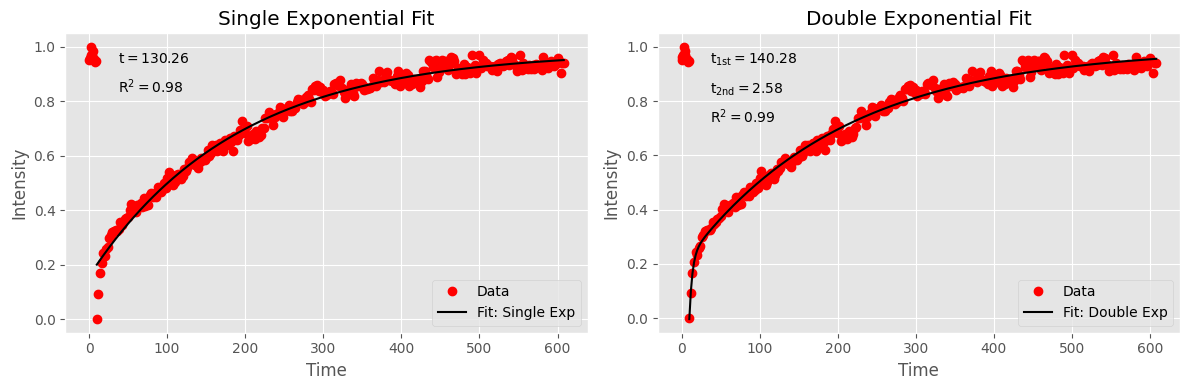

  Results - Single exp t½: 130.26, R²: 0.984
           Double exp t½1: 140.28, t½2: 2.58, R²: 0.989
--------------------------------------------------
Processing cell: results_FRAP_20250709 pRS046_050 FRAP_9 (subfolder: results_FRAP_20250709 pRS046_050 FRAP, image: FRAP 018) with 310 frames


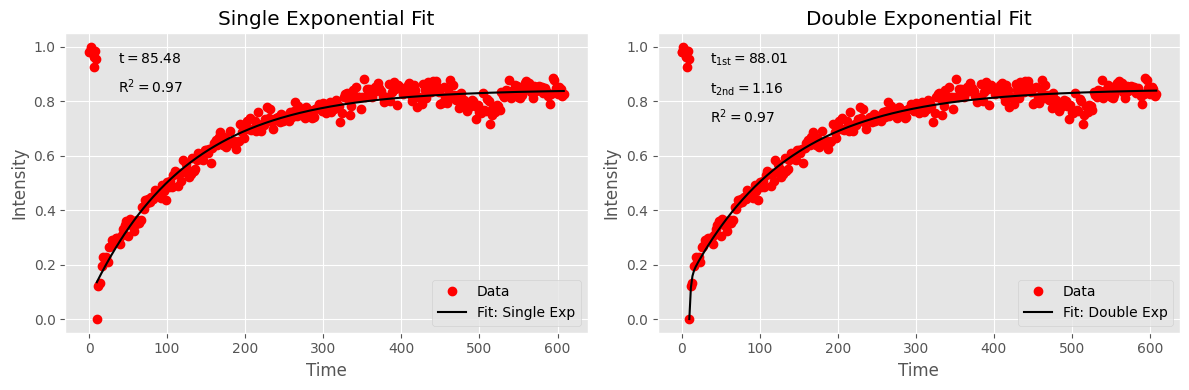

  Results - Single exp t½: 85.48, R²: 0.969
           Double exp t½1: 88.01, t½2: 1.16, R²: 0.971
--------------------------------------------------
Processing cell: results_FRAP_20250709 pRS046_050 FRAP_10 (subfolder: results_FRAP_20250709 pRS046_050 FRAP, image: FRAP 019) with 310 frames


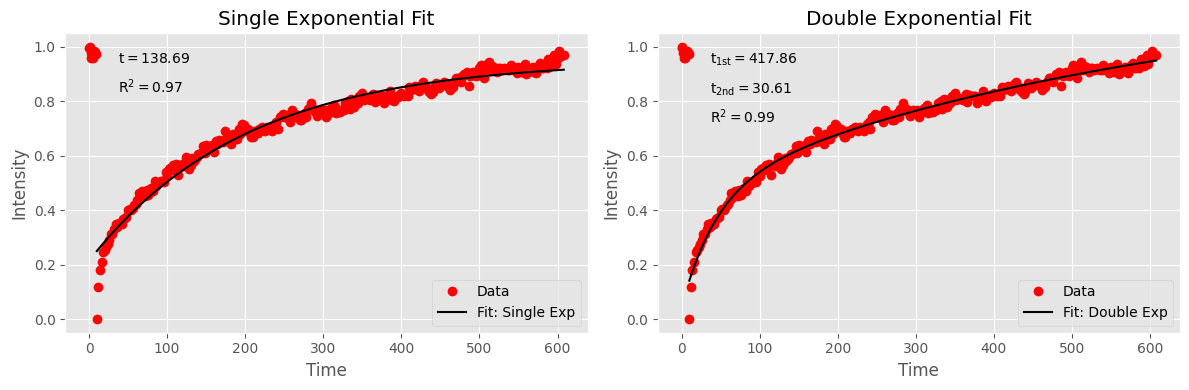

  Results - Single exp t½: 138.69, R²: 0.974
           Double exp t½1: 417.86, t½2: 30.61, R²: 0.990
--------------------------------------------------
Processing cell: results_FRAP_20250709 pRS046_050 FRAP_11 (subfolder: results_FRAP_20250709 pRS046_050 FRAP, image: FRAP 020) with 310 frames


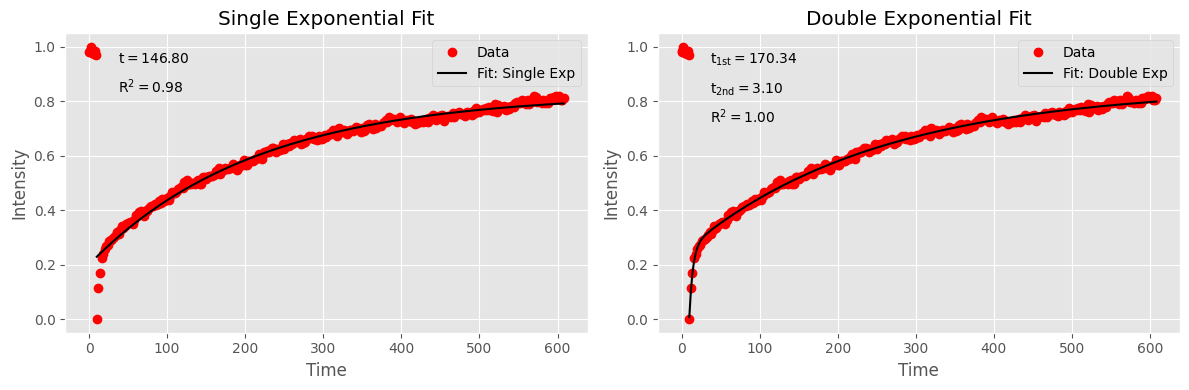

  Results - Single exp t½: 146.80, R²: 0.984
           Double exp t½1: 170.34, t½2: 3.10, R²: 0.996
--------------------------------------------------
Processing cell: results_FRAP_20250709 pRS046_050 FRAP_12 (subfolder: results_FRAP_20250709 pRS046_050 FRAP, image: FRAP 021) with 310 frames


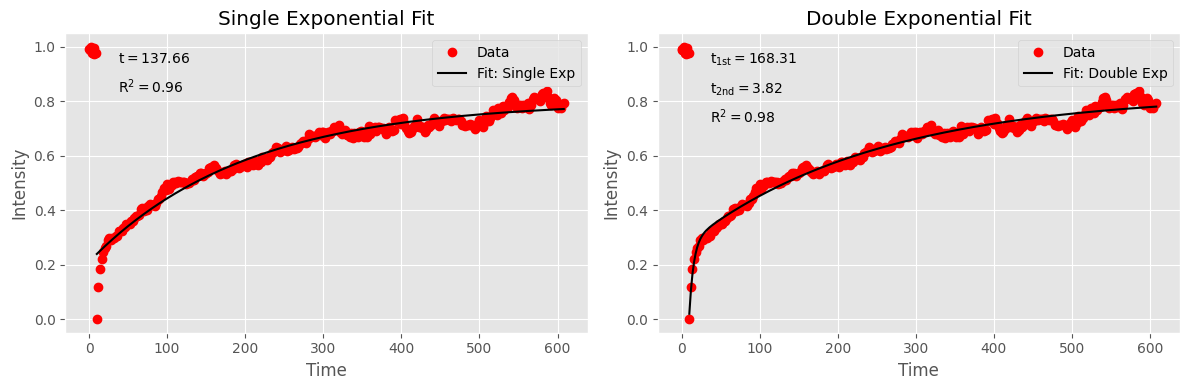

  Results - Single exp t½: 137.66, R²: 0.964
           Double exp t½1: 168.31, t½2: 3.82, R²: 0.980
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS046_050 FRAP_1 (subfolder: results_FRAP_20250820 pRS046_050 FRAP, image: FRAP 002) with 310 frames


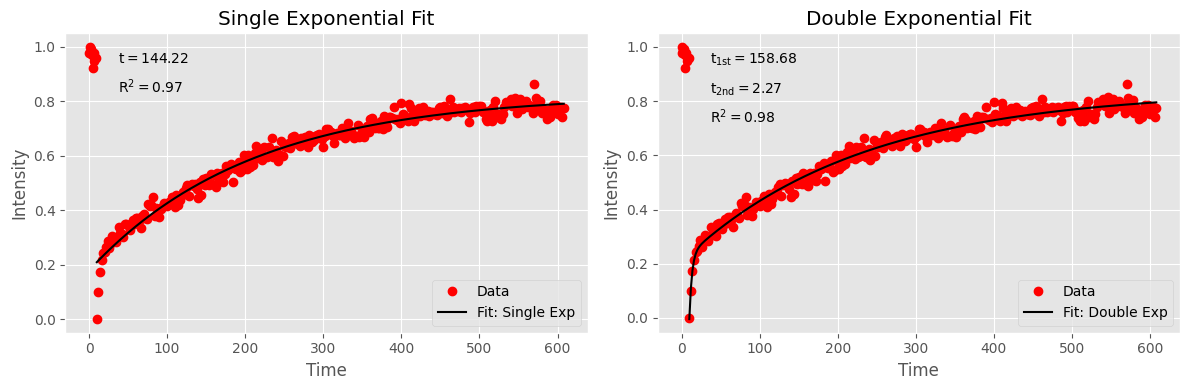

  Results - Single exp t½: 144.22, R²: 0.973
           Double exp t½1: 158.68, t½2: 2.27, R²: 0.982
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS046_050 FRAP_2 (subfolder: results_FRAP_20250820 pRS046_050 FRAP, image: FRAP 003) with 310 frames


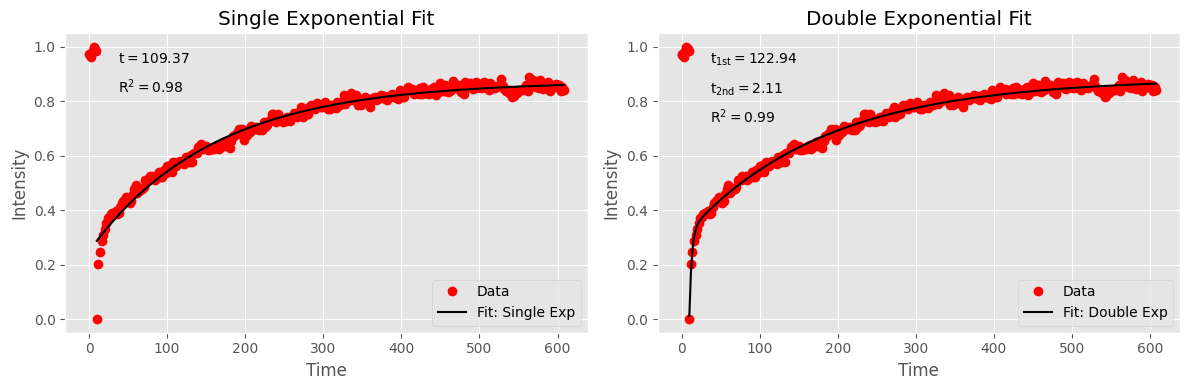

  Results - Single exp t½: 109.37, R²: 0.976
           Double exp t½1: 122.94, t½2: 2.11, R²: 0.992
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS046_050 FRAP_3 (subfolder: results_FRAP_20250820 pRS046_050 FRAP, image: FRAP 004) with 310 frames


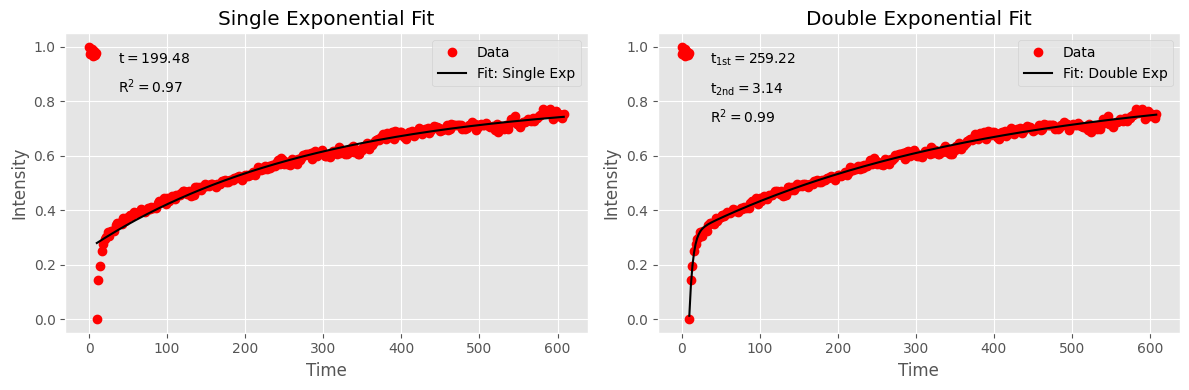

  Results - Single exp t½: 199.48, R²: 0.968
           Double exp t½1: 259.22, t½2: 3.14, R²: 0.992
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS046_050 FRAP_4 (subfolder: results_FRAP_20250820 pRS046_050 FRAP, image: FRAP 005) with 310 frames


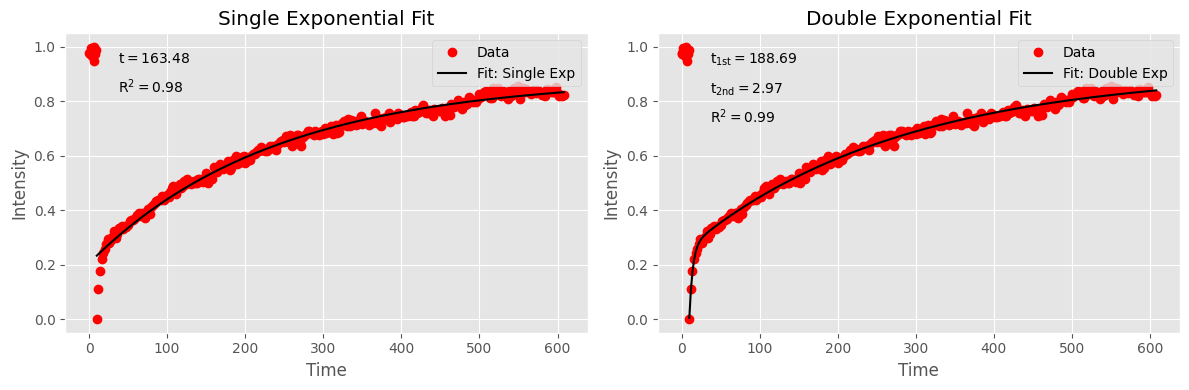

  Results - Single exp t½: 163.48, R²: 0.983
           Double exp t½1: 188.69, t½2: 2.97, R²: 0.994
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS046_050 FRAP_5 (subfolder: results_FRAP_20250820 pRS046_050 FRAP, image: FRAP 007) with 310 frames


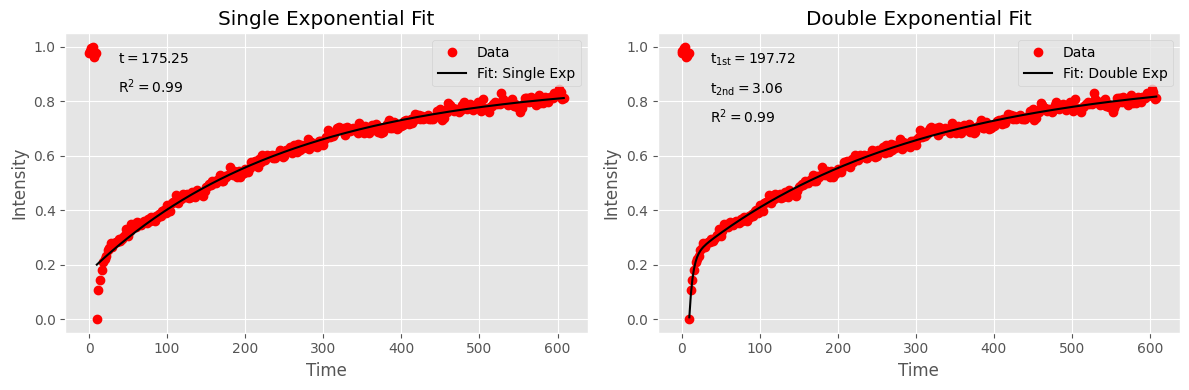

  Results - Single exp t½: 175.25, R²: 0.987
           Double exp t½1: 197.72, t½2: 3.06, R²: 0.994
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS046_050 FRAP_6 (subfolder: results_FRAP_20250820 pRS046_050 FRAP, image: FRAP 008) with 310 frames


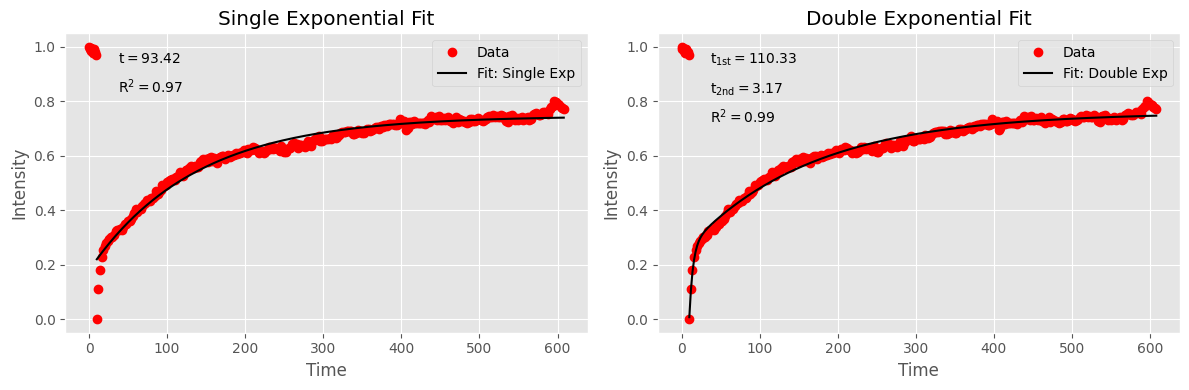

  Results - Single exp t½: 93.42, R²: 0.970
           Double exp t½1: 110.33, t½2: 3.17, R²: 0.985
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS046_050 FRAP_7 (subfolder: results_FRAP_20250820 pRS046_050 FRAP, image: FRAP 009) with 310 frames


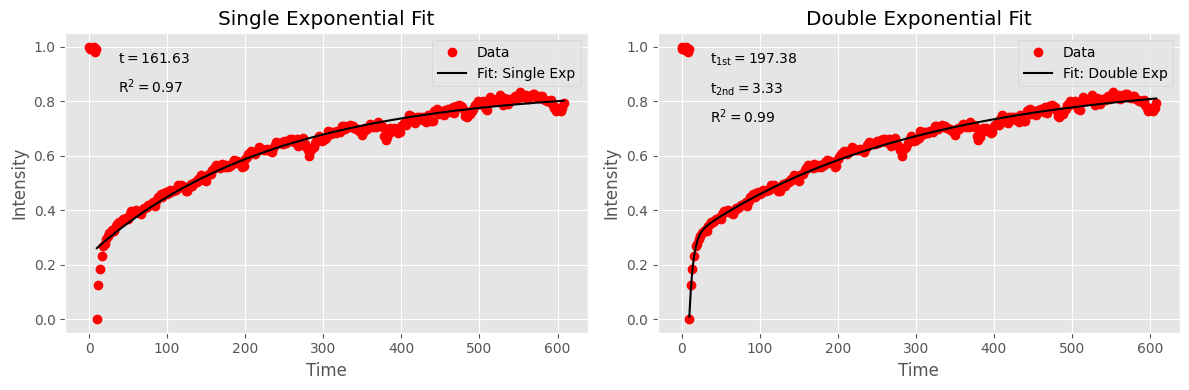

  Results - Single exp t½: 161.63, R²: 0.970
           Double exp t½1: 197.38, t½2: 3.33, R²: 0.987
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS046_050 FRAP_8 (subfolder: results_FRAP_20250820 pRS046_050 FRAP, image: FRAP 010) with 310 frames


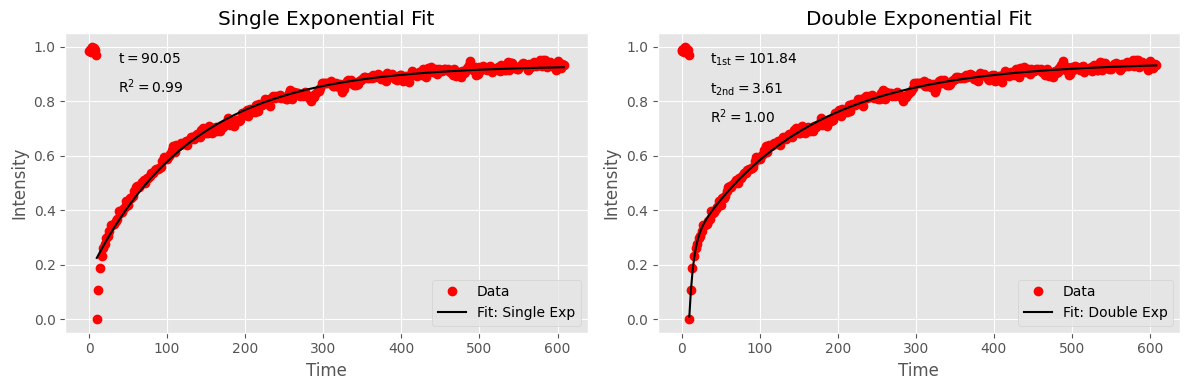

  Results - Single exp t½: 90.05, R²: 0.986
           Double exp t½1: 101.84, t½2: 3.61, R²: 0.995
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS046_050 FRAP_9 (subfolder: results_FRAP_20250820 pRS046_050 FRAP, image: FRAP 011) with 310 frames


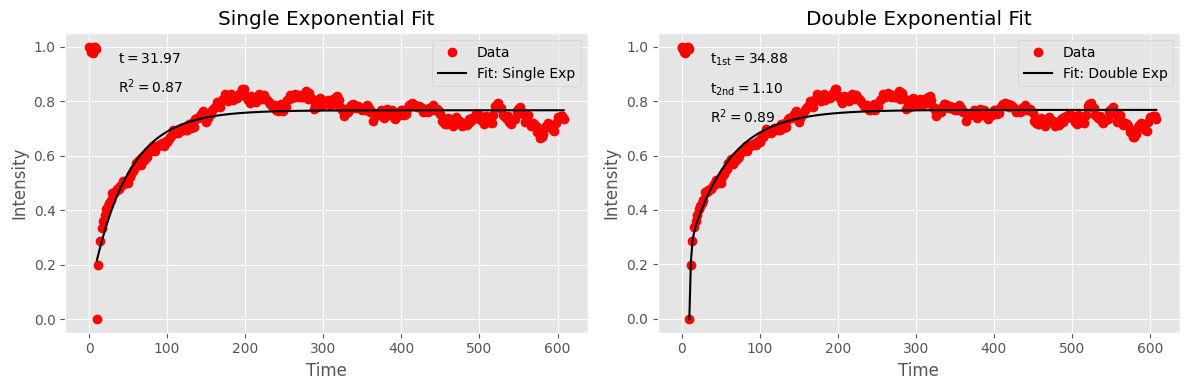

  Results - Single exp t½: 31.97, R²: 0.870
           Double exp t½1: 34.88, t½2: 1.10, R²: 0.887
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS046_050 FRAP_10 (subfolder: results_FRAP_20250820 pRS046_050 FRAP, image: FRAP 012) with 310 frames


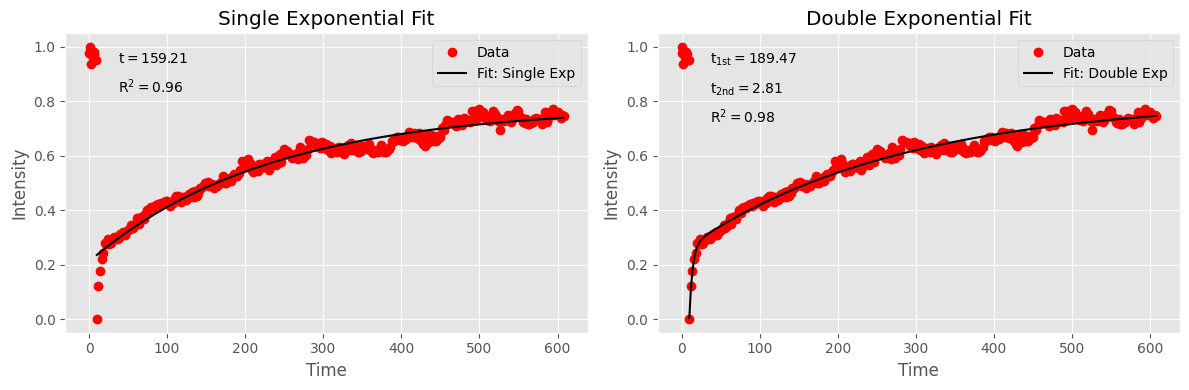

  Results - Single exp t½: 159.21, R²: 0.963
           Double exp t½1: 189.47, t½2: 2.81, R²: 0.978
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS046_050 FRAP_11 (subfolder: results_FRAP_20250820 pRS046_050 FRAP, image: FRAP 013) with 310 frames


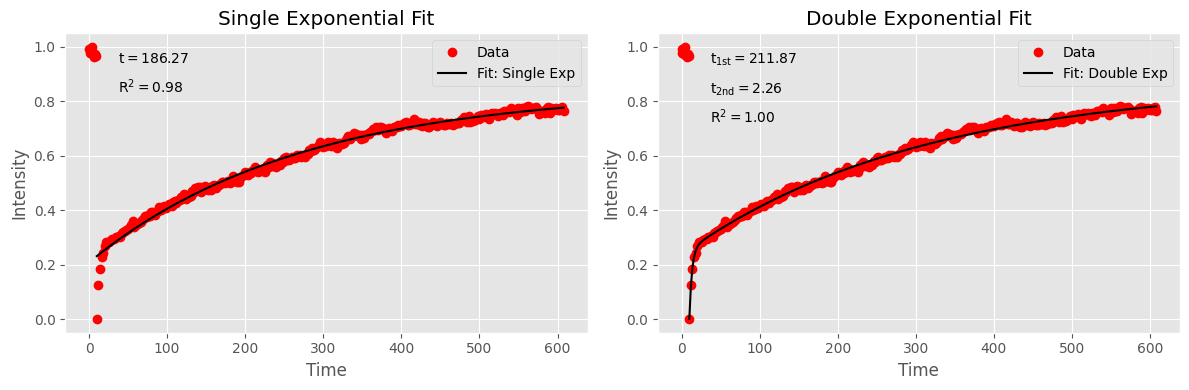

  Results - Single exp t½: 186.27, R²: 0.984
           Double exp t½1: 211.87, t½2: 2.26, R²: 0.995
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS046_050 FRAP_12 (subfolder: results_FRAP_20250820 pRS046_050 FRAP, image: FRAP 014) with 310 frames


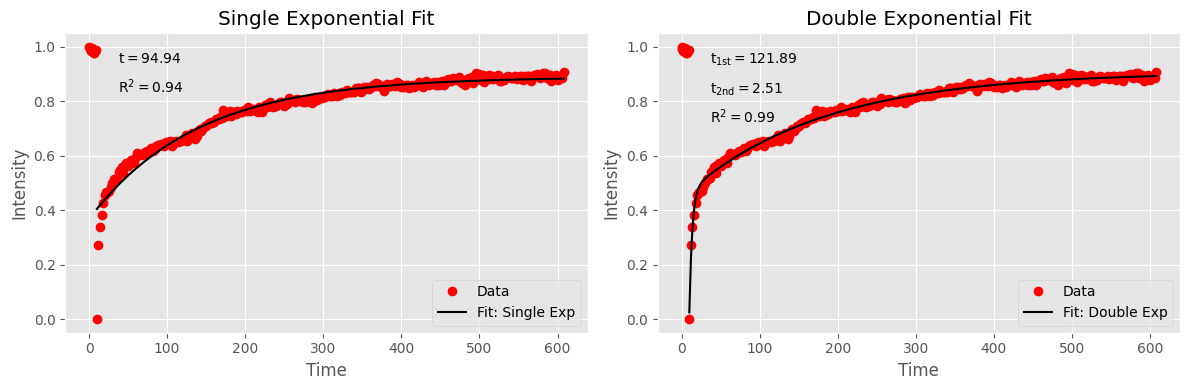

  Results - Single exp t½: 94.94, R²: 0.944
           Double exp t½1: 121.89, t½2: 2.51, R²: 0.993
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS046_050 FRAP_13 (subfolder: results_FRAP_20250820 pRS046_050 FRAP, image: FRAP 015) with 310 frames


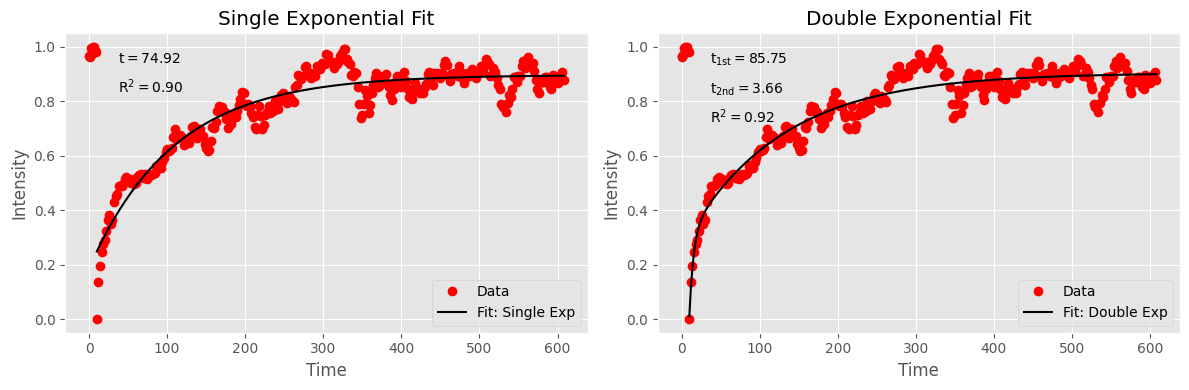

  Results - Single exp t½: 74.92, R²: 0.902
           Double exp t½1: 85.75, t½2: 3.66, R²: 0.917
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS046_050 FRAP_14 (subfolder: results_FRAP_20250820 pRS046_050 FRAP, image: FRAP 016) with 310 frames


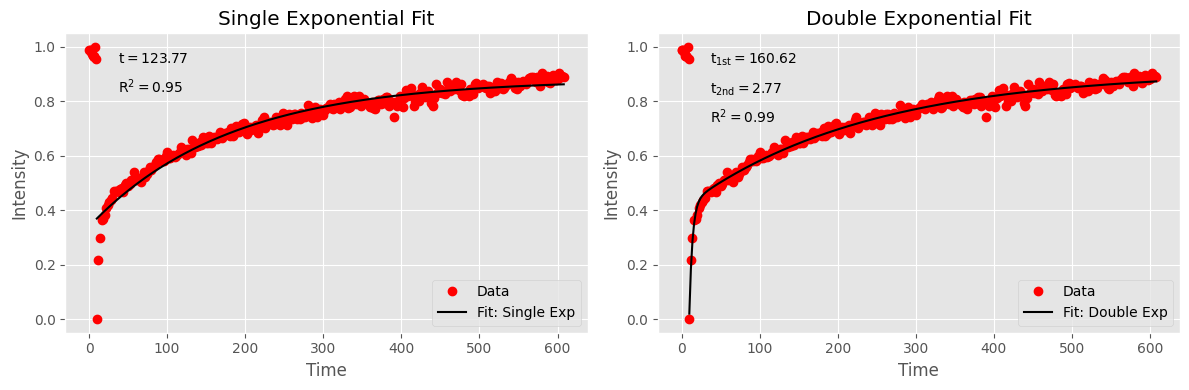

  Results - Single exp t½: 123.77, R²: 0.948
           Double exp t½1: 160.62, t½2: 2.77, R²: 0.986
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS046_050 FRAP_15 (subfolder: results_FRAP_20250820 pRS046_050 FRAP, image: FRAP 017) with 310 frames


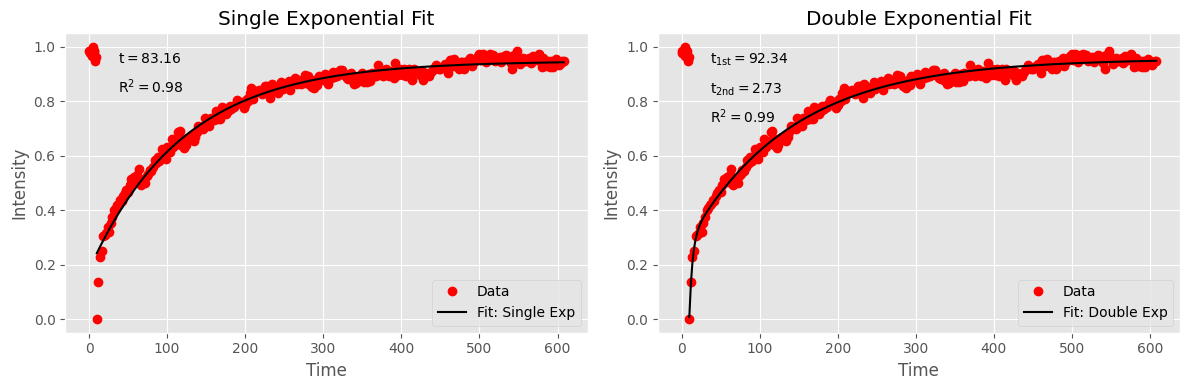

  Results - Single exp t½: 83.16, R²: 0.979
           Double exp t½1: 92.34, t½2: 2.73, R²: 0.989
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS046_050 FRAP_16 (subfolder: results_FRAP_20250820 pRS046_050 FRAP, image: FRAP 018) with 310 frames


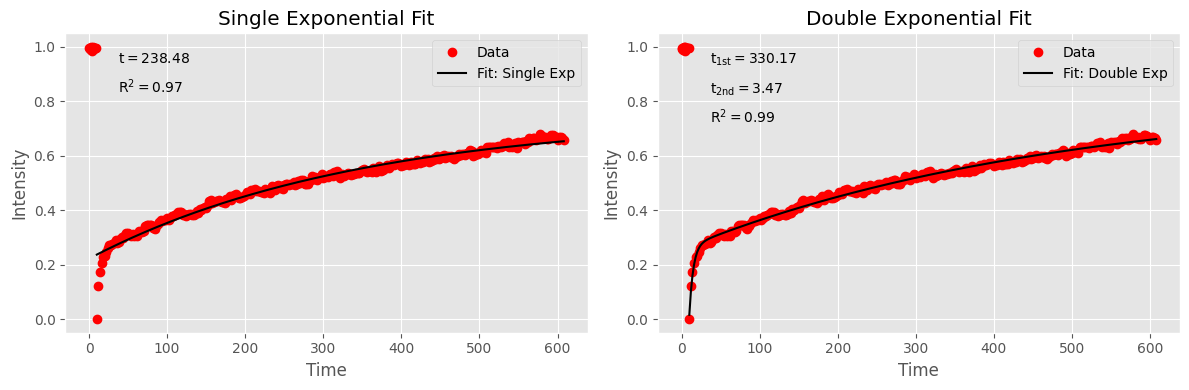

  Results - Single exp t½: 238.48, R²: 0.971
           Double exp t½1: 330.17, t½2: 3.47, R²: 0.993
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS046_050 FRAP_17 (subfolder: results_FRAP_20250820 pRS046_050 FRAP, image: FRAP 019) with 310 frames


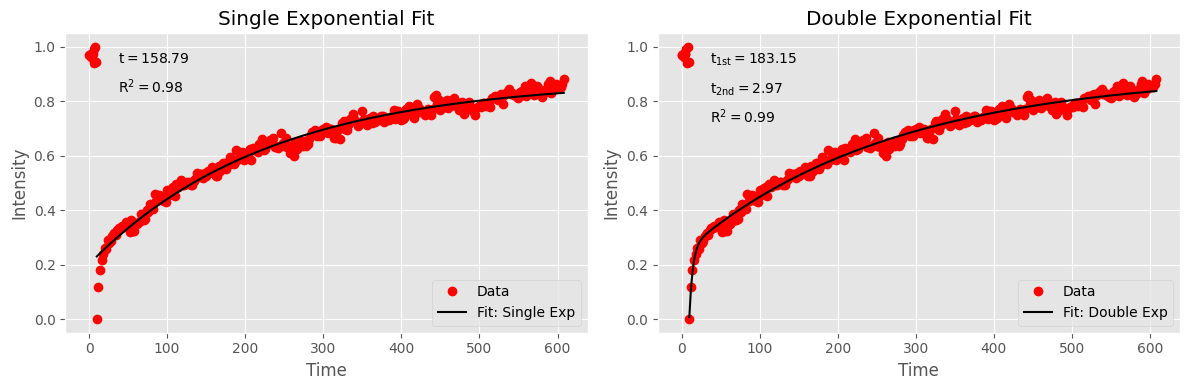

  Results - Single exp t½: 158.79, R²: 0.977
           Double exp t½1: 183.15, t½2: 2.97, R²: 0.987
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS046_050 FRAP_18 (subfolder: results_FRAP_20250820 pRS046_050 FRAP, image: FRAP 020) with 310 frames


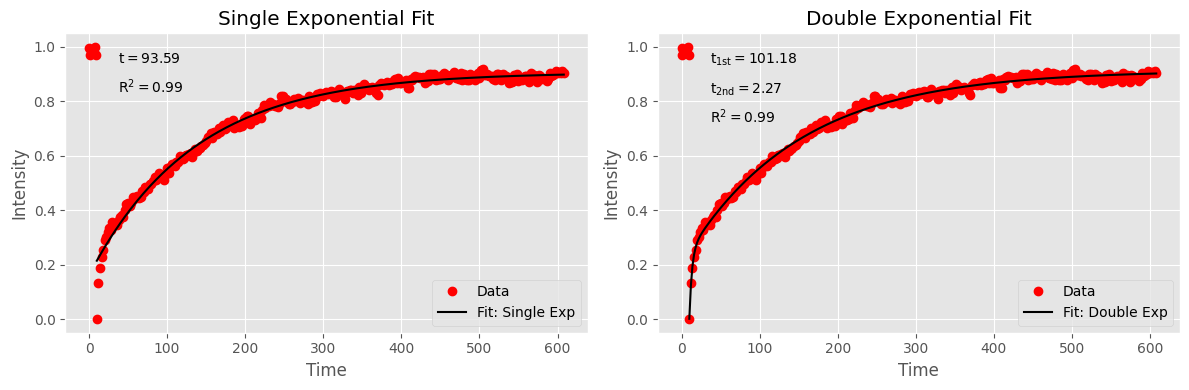

  Results - Single exp t½: 93.59, R²: 0.987
           Double exp t½1: 101.18, t½2: 2.27, R²: 0.995
--------------------------------------------------

Processing dataset: uv
Found 32 unique cells in 'uv' dataset
Processing cell: results_FRAP_20250820 pRS056_050 FRAP_1 (subfolder: results_FRAP_20250820 pRS056_050 FRAP, image: FRAP 001) with 310 frames


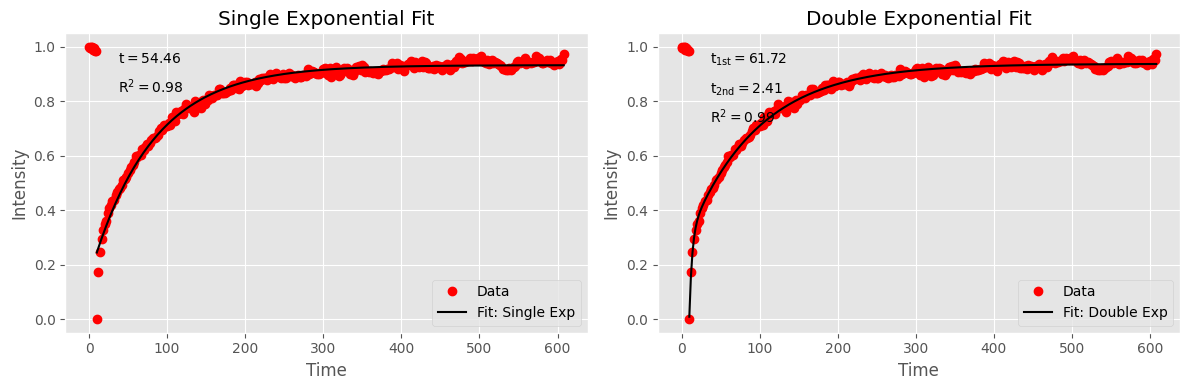

  Results - Single exp t½: 54.46, R²: 0.982
           Double exp t½1: 61.72, t½2: 2.41, R²: 0.994
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS056_050 FRAP_2 (subfolder: results_FRAP_20250820 pRS056_050 FRAP, image: FRAP 002) with 310 frames


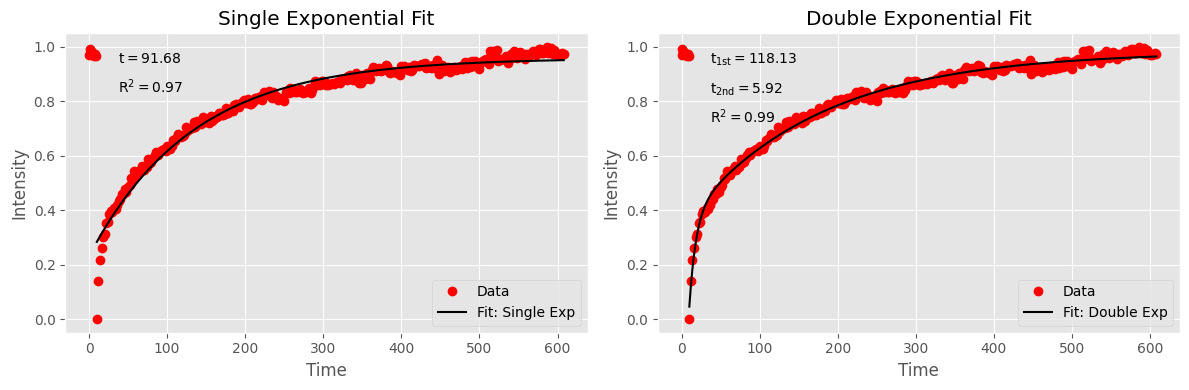

  Results - Single exp t½: 91.68, R²: 0.973
           Double exp t½1: 118.13, t½2: 5.92, R²: 0.992
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS056_050 FRAP_3 (subfolder: results_FRAP_20250820 pRS056_050 FRAP, image: FRAP 003) with 310 frames


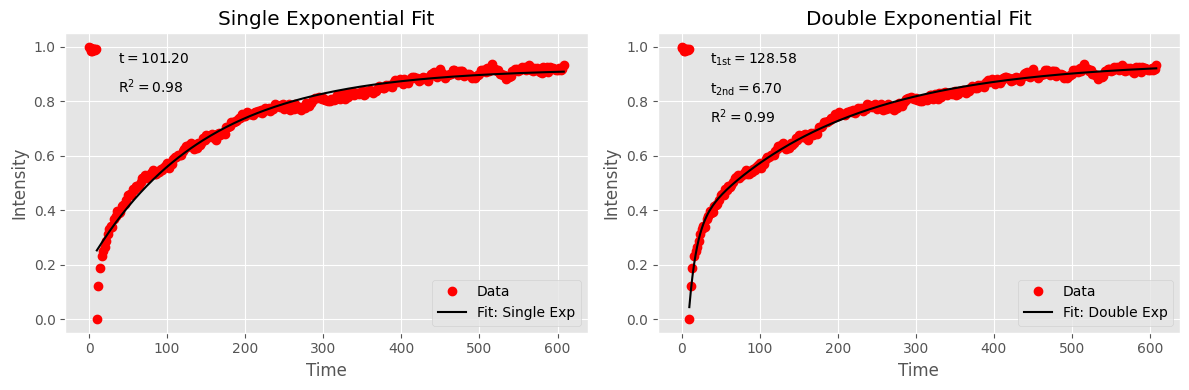

  Results - Single exp t½: 101.20, R²: 0.979
           Double exp t½1: 128.58, t½2: 6.70, R²: 0.994
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS056_050 FRAP_4 (subfolder: results_FRAP_20250820 pRS056_050 FRAP, image: FRAP 004) with 310 frames


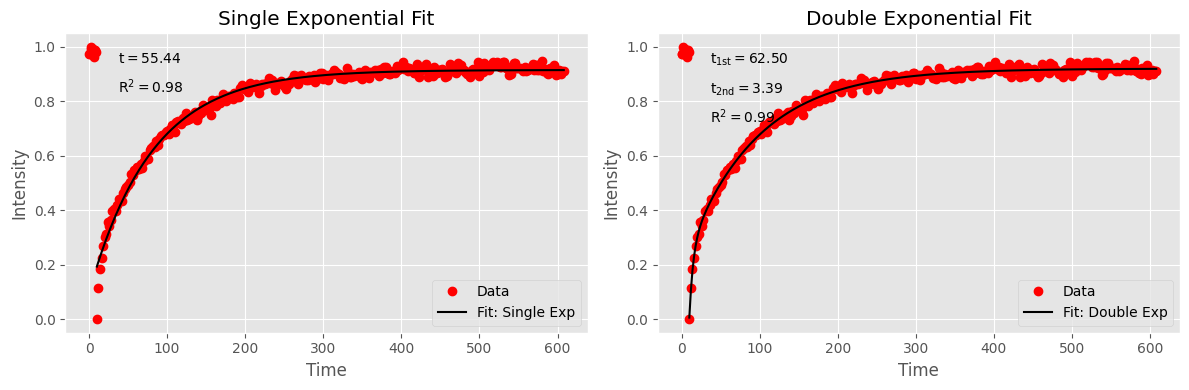

  Results - Single exp t½: 55.44, R²: 0.985
           Double exp t½1: 62.50, t½2: 3.39, R²: 0.994
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS056_050 FRAP_5 (subfolder: results_FRAP_20250820 pRS056_050 FRAP, image: FRAP 009) with 310 frames


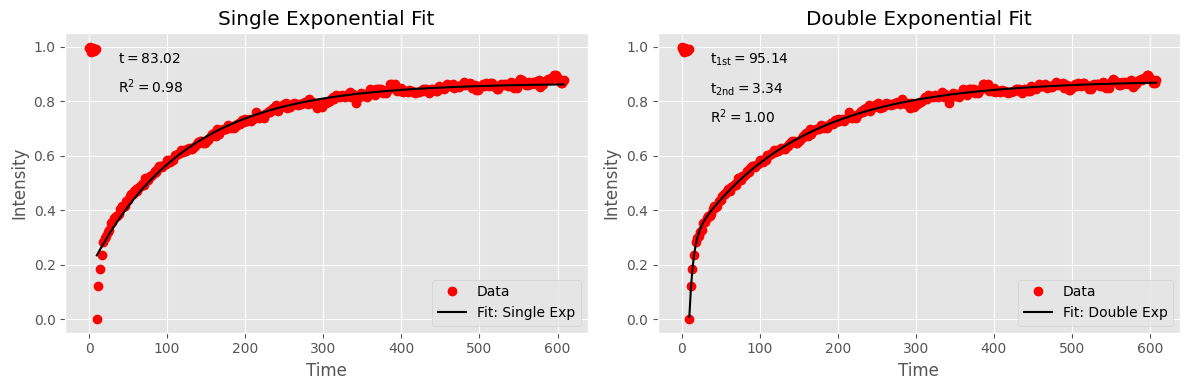

  Results - Single exp t½: 83.02, R²: 0.983
           Double exp t½1: 95.14, t½2: 3.34, R²: 0.997
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS056_050 FRAP_6 (subfolder: results_FRAP_20250820 pRS056_050 FRAP, image: FRAP 010) with 310 frames


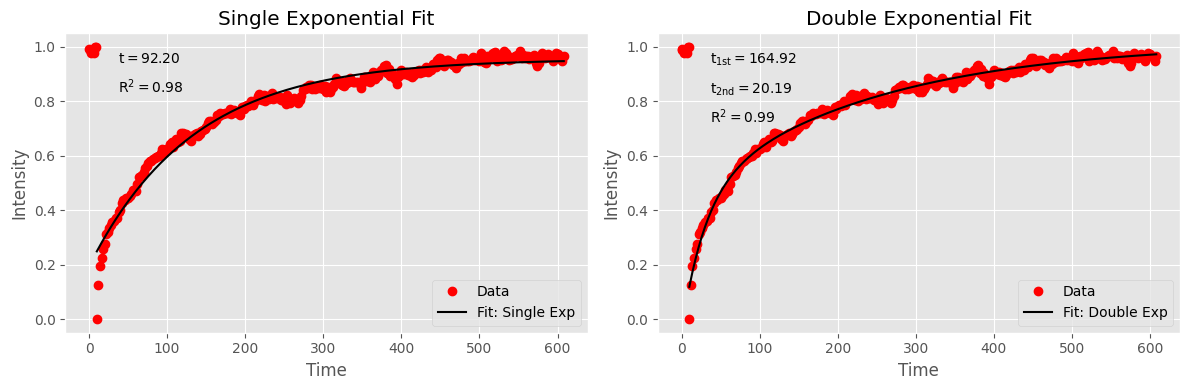

  Results - Single exp t½: 92.20, R²: 0.975
           Double exp t½1: 164.92, t½2: 20.19, R²: 0.991
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS056_050 FRAP_7 (subfolder: results_FRAP_20250820 pRS056_050 FRAP, image: FRAP 014) with 310 frames


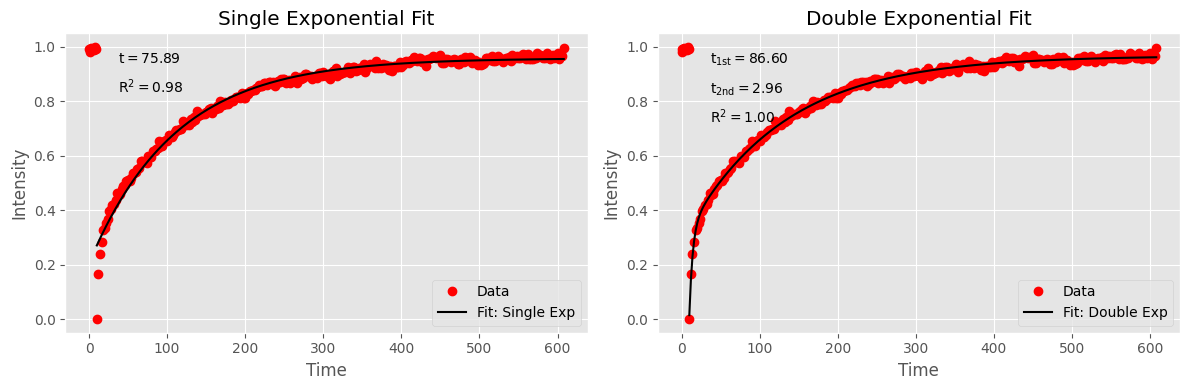

  Results - Single exp t½: 75.89, R²: 0.983
           Double exp t½1: 86.60, t½2: 2.96, R²: 0.997
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS056_050 FRAP_8 (subfolder: results_FRAP_20250820 pRS056_050 FRAP, image: FRAP 015) with 310 frames


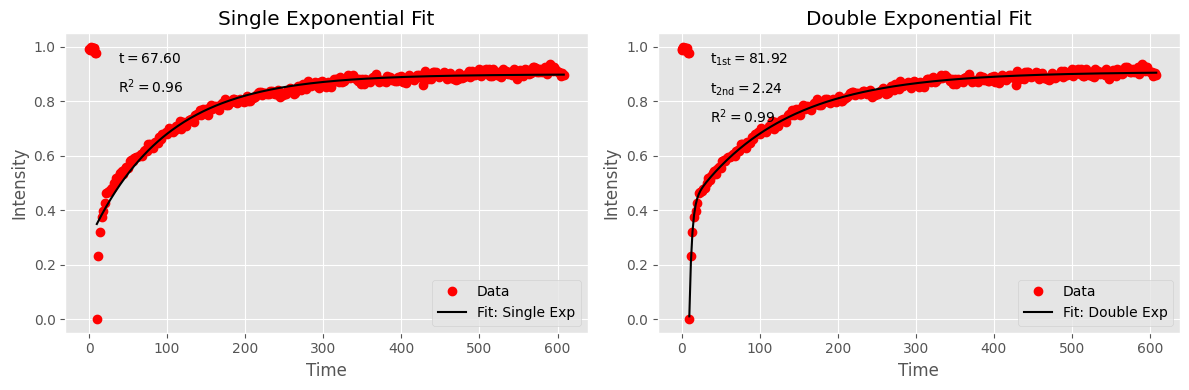

  Results - Single exp t½: 67.60, R²: 0.960
           Double exp t½1: 81.92, t½2: 2.24, R²: 0.994
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS056_050 FRAP_9 (subfolder: results_FRAP_20250820 pRS056_050 FRAP, image: FRAP 016) with 310 frames


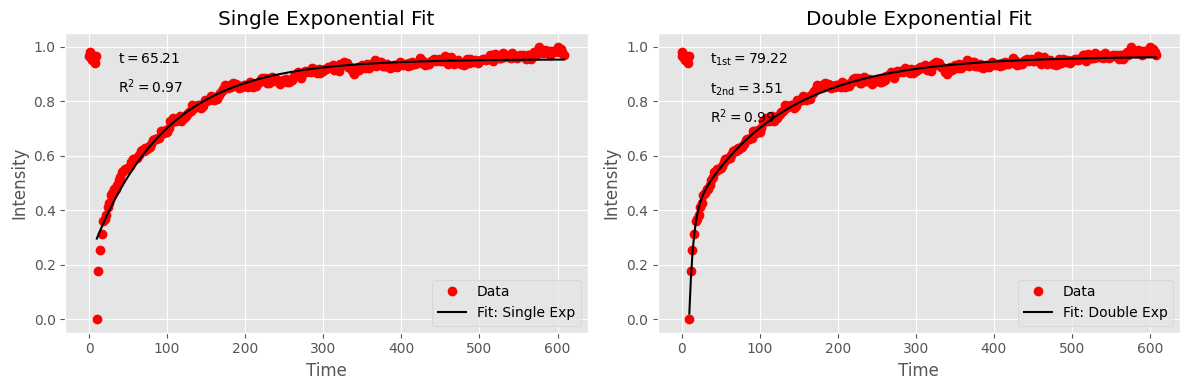

  Results - Single exp t½: 65.21, R²: 0.973
           Double exp t½1: 79.22, t½2: 3.51, R²: 0.994
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS056_050 FRAP_10 (subfolder: results_FRAP_20250820 pRS056_050 FRAP, image: FRAP 017) with 310 frames


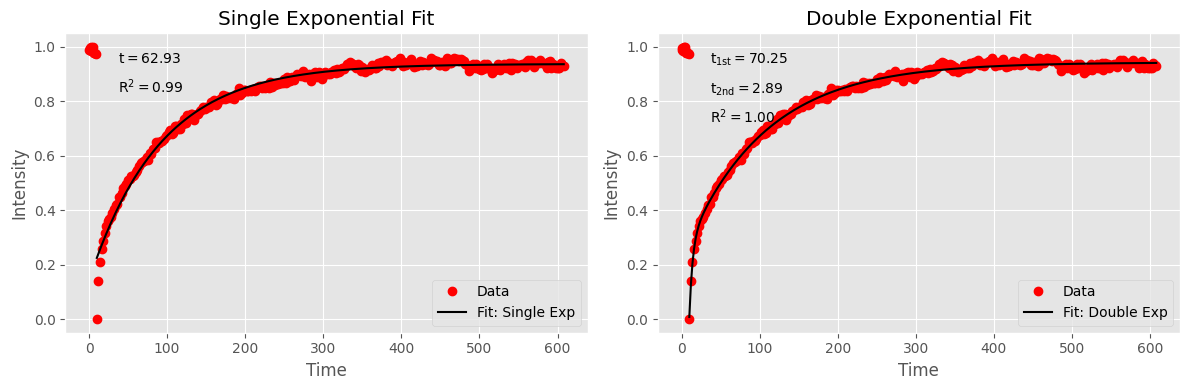

  Results - Single exp t½: 62.93, R²: 0.985
           Double exp t½1: 70.25, t½2: 2.89, R²: 0.995
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS056_050 FRAP_11 (subfolder: results_FRAP_20250820 pRS056_050 FRAP, image: FRAP 018) with 310 frames


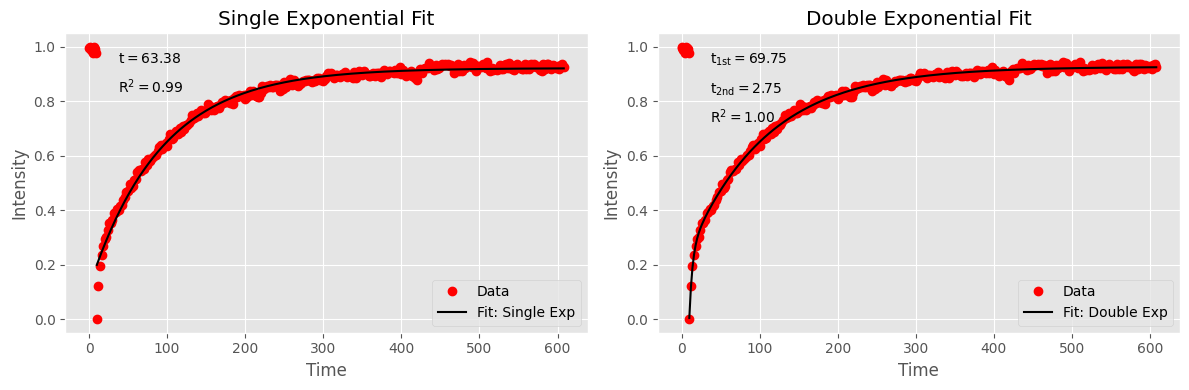

  Results - Single exp t½: 63.38, R²: 0.989
           Double exp t½1: 69.75, t½2: 2.75, R²: 0.996
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS056_050 FRAP_12 (subfolder: results_FRAP_20250820 pRS056_050 FRAP, image: FRAP 019) with 310 frames


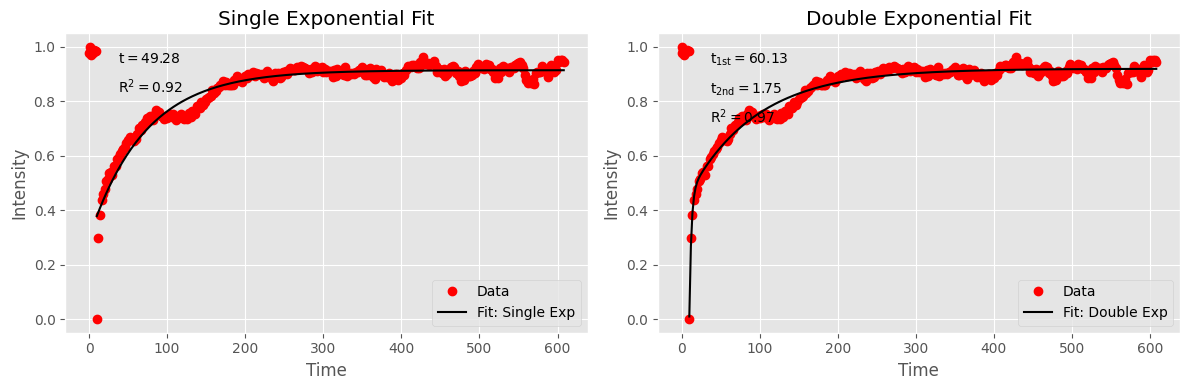

  Results - Single exp t½: 49.28, R²: 0.922
           Double exp t½1: 60.13, t½2: 1.75, R²: 0.966
--------------------------------------------------
Processing cell: results_FRAP_20250820 pRS056_050 FRAP_13 (subfolder: results_FRAP_20250820 pRS056_050 FRAP, image: FRAP 020) with 310 frames


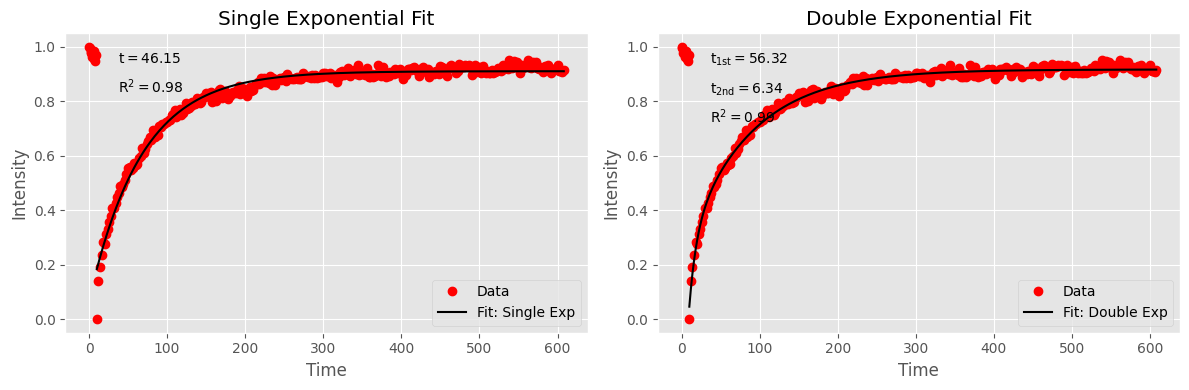

  Results - Single exp t½: 46.15, R²: 0.983
           Double exp t½1: 56.32, t½2: 6.34, R²: 0.992
--------------------------------------------------
Processing cell: results_FRAP_20250828 pRS056_050 FRAP_1 (subfolder: results_FRAP_20250828 pRS056_050 FRAP, image: FRAP 001) with 310 frames


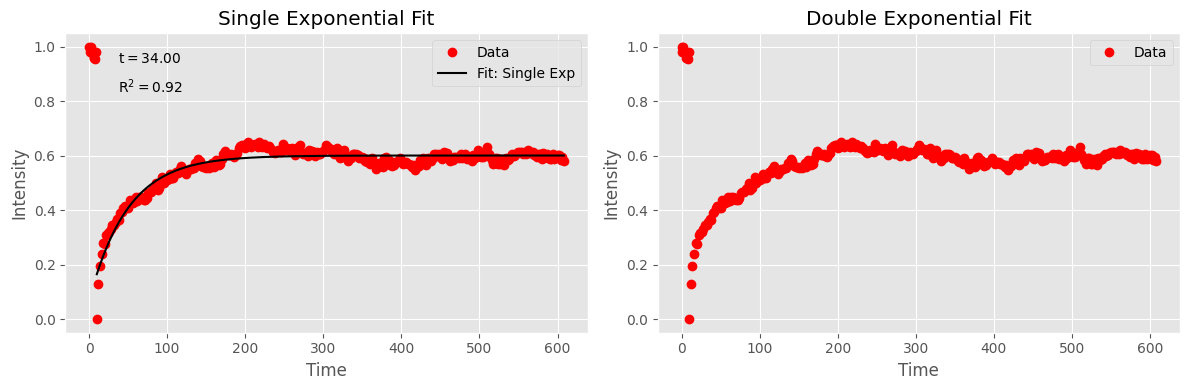

  Results - Single exp t½: 34.00, R²: 0.918
           Double exp t½1: nan, t½2: nan, R²: nan
--------------------------------------------------
Processing cell: results_FRAP_20250828 pRS056_050 FRAP_2 (subfolder: results_FRAP_20250828 pRS056_050 FRAP, image: FRAP 002) with 310 frames


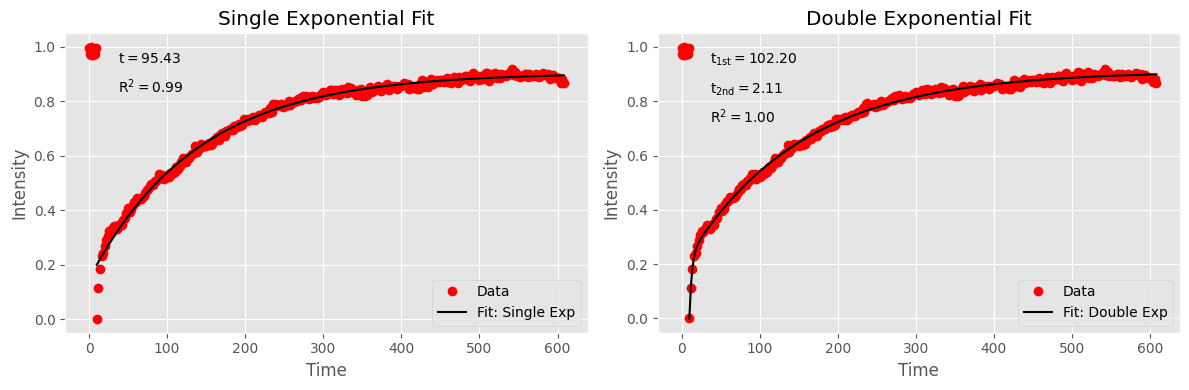

  Results - Single exp t½: 95.43, R²: 0.990
           Double exp t½1: 102.20, t½2: 2.11, R²: 0.996
--------------------------------------------------
Processing cell: results_FRAP_20250828 pRS056_050 FRAP_3 (subfolder: results_FRAP_20250828 pRS056_050 FRAP, image: FRAP 003) with 310 frames


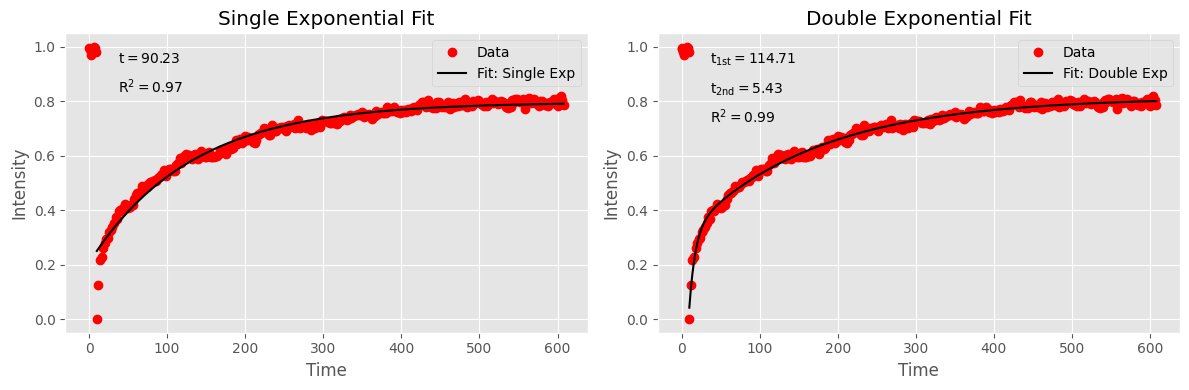

  Results - Single exp t½: 90.23, R²: 0.972
           Double exp t½1: 114.71, t½2: 5.43, R²: 0.992
--------------------------------------------------
Processing cell: results_FRAP_20250828 pRS056_050 FRAP_4 (subfolder: results_FRAP_20250828 pRS056_050 FRAP, image: FRAP 004) with 310 frames


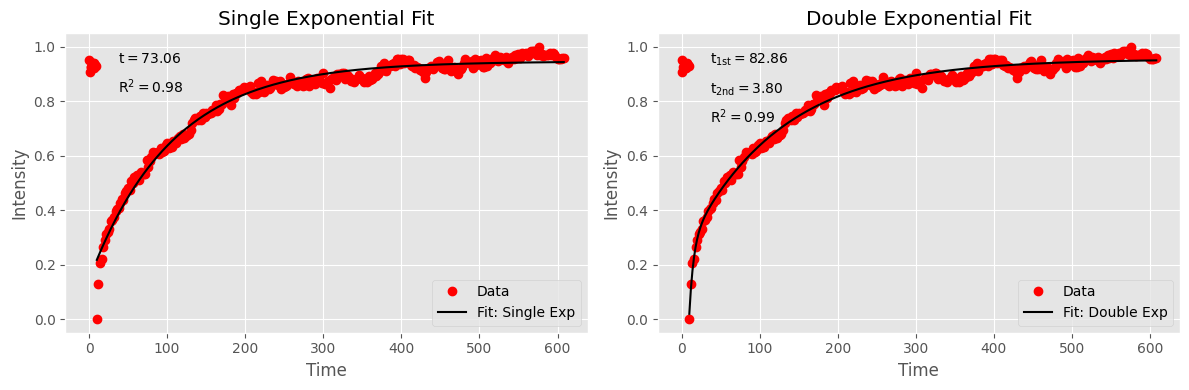

  Results - Single exp t½: 73.06, R²: 0.980
           Double exp t½1: 82.86, t½2: 3.80, R²: 0.988
--------------------------------------------------
Processing cell: results_FRAP_20250828 pRS056_050 FRAP_5 (subfolder: results_FRAP_20250828 pRS056_050 FRAP, image: FRAP 005) with 310 frames


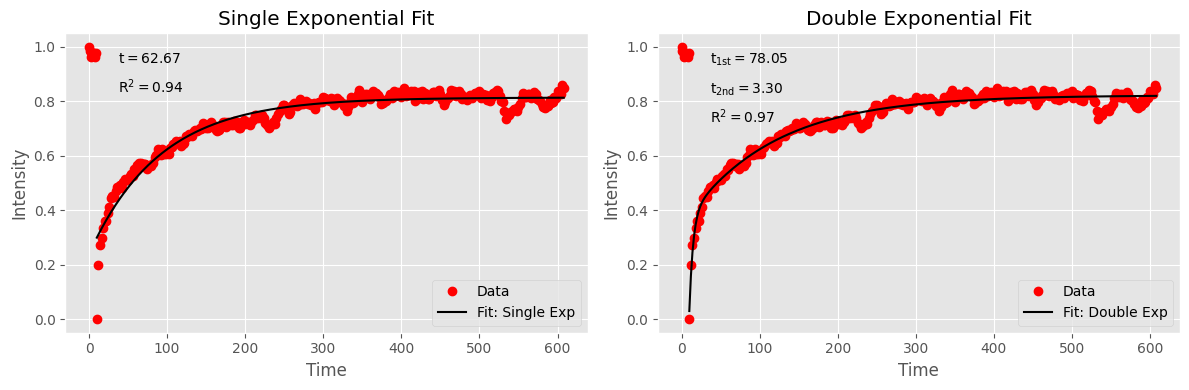

  Results - Single exp t½: 62.67, R²: 0.941
           Double exp t½1: 78.05, t½2: 3.30, R²: 0.972
--------------------------------------------------
Processing cell: results_FRAP_20250828 pRS056_050 FRAP_6 (subfolder: results_FRAP_20250828 pRS056_050 FRAP, image: FRAP 006) with 310 frames


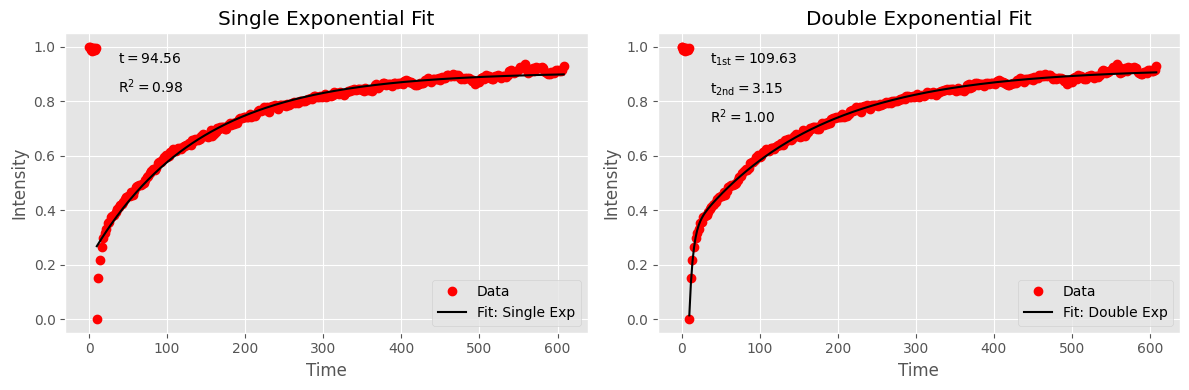

  Results - Single exp t½: 94.56, R²: 0.981
           Double exp t½1: 109.63, t½2: 3.15, R²: 0.996
--------------------------------------------------
Processing cell: results_FRAP_20250828 pRS056_050 FRAP_7 (subfolder: results_FRAP_20250828 pRS056_050 FRAP, image: FRAP 007) with 310 frames


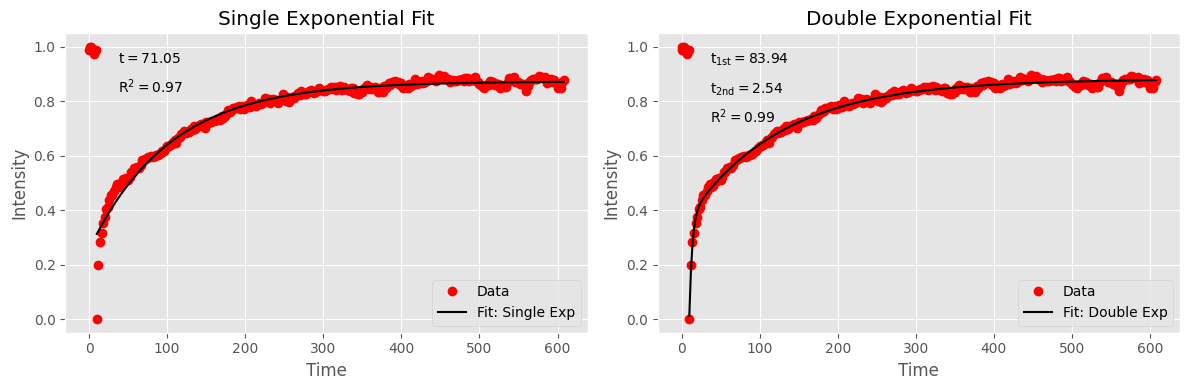

  Results - Single exp t½: 71.05, R²: 0.967
           Double exp t½1: 83.94, t½2: 2.54, R²: 0.994
--------------------------------------------------
Processing cell: results_FRAP_20250828 pRS056_050 FRAP_8 (subfolder: results_FRAP_20250828 pRS056_050 FRAP, image: FRAP 008) with 310 frames


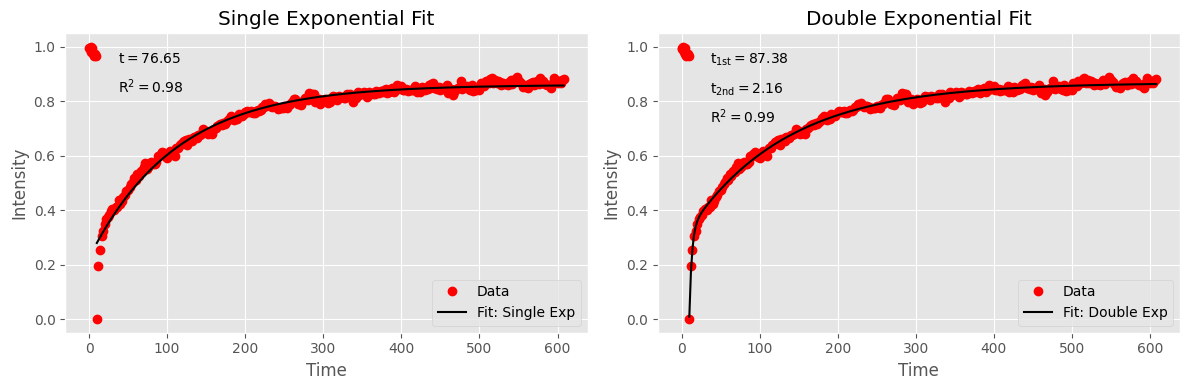

  Results - Single exp t½: 76.65, R²: 0.976
           Double exp t½1: 87.38, t½2: 2.16, R²: 0.994
--------------------------------------------------
Processing cell: results_FRAP_20250828 pRS056_050 FRAP_9 (subfolder: results_FRAP_20250828 pRS056_050 FRAP, image: FRAP 009) with 310 frames


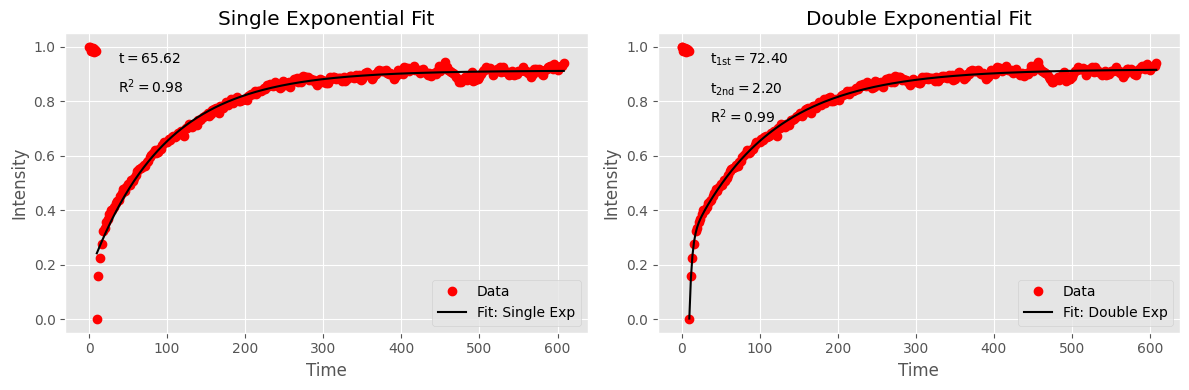

  Results - Single exp t½: 65.62, R²: 0.983
           Double exp t½1: 72.40, t½2: 2.20, R²: 0.994
--------------------------------------------------
Processing cell: results_FRAP_20250828 pRS056_050 FRAP_10 (subfolder: results_FRAP_20250828 pRS056_050 FRAP, image: FRAP 010) with 310 frames


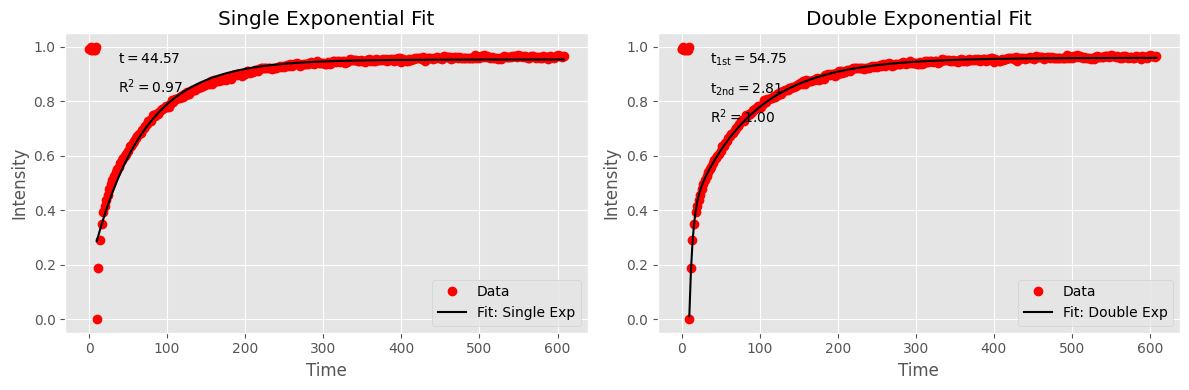

  Results - Single exp t½: 44.57, R²: 0.975
           Double exp t½1: 54.75, t½2: 2.81, R²: 0.999
--------------------------------------------------
Processing cell: results_FRAP_20250828 pRS056_050 FRAP_11 (subfolder: results_FRAP_20250828 pRS056_050 FRAP, image: FRAP 011) with 310 frames


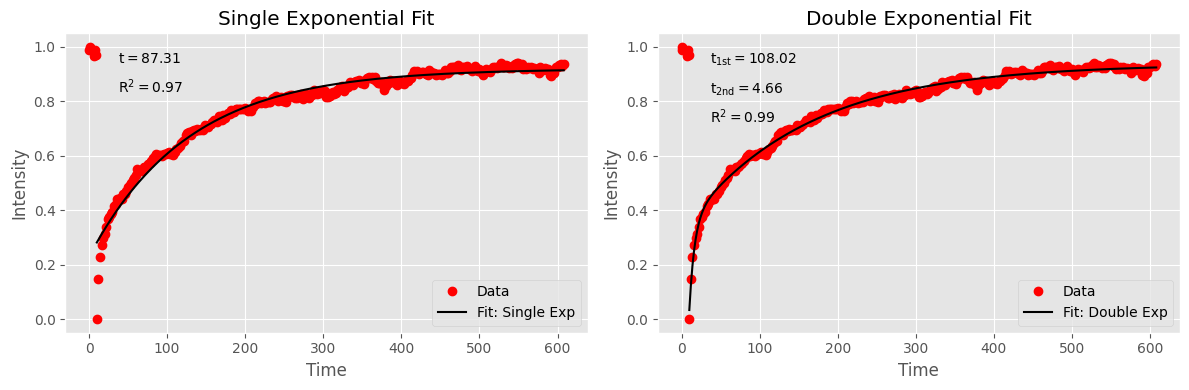

  Results - Single exp t½: 87.31, R²: 0.974
           Double exp t½1: 108.02, t½2: 4.66, R²: 0.993
--------------------------------------------------
Processing cell: results_FRAP_20250828 pRS056_050 FRAP_12 (subfolder: results_FRAP_20250828 pRS056_050 FRAP, image: FRAP 012) with 310 frames


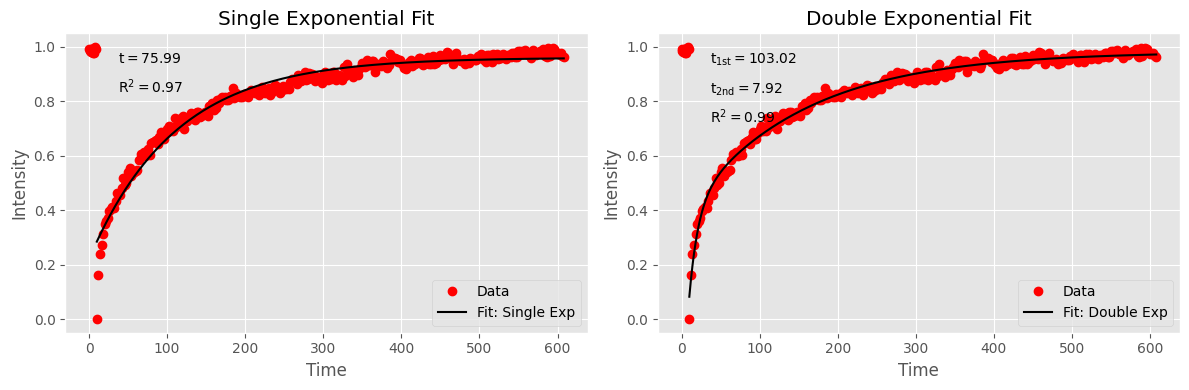

  Results - Single exp t½: 75.99, R²: 0.971
           Double exp t½1: 103.02, t½2: 7.92, R²: 0.990
--------------------------------------------------
Processing cell: results_FRAP_20250828 pRS056_050 FRAP_13 (subfolder: results_FRAP_20250828 pRS056_050 FRAP, image: FRAP 014) with 310 frames


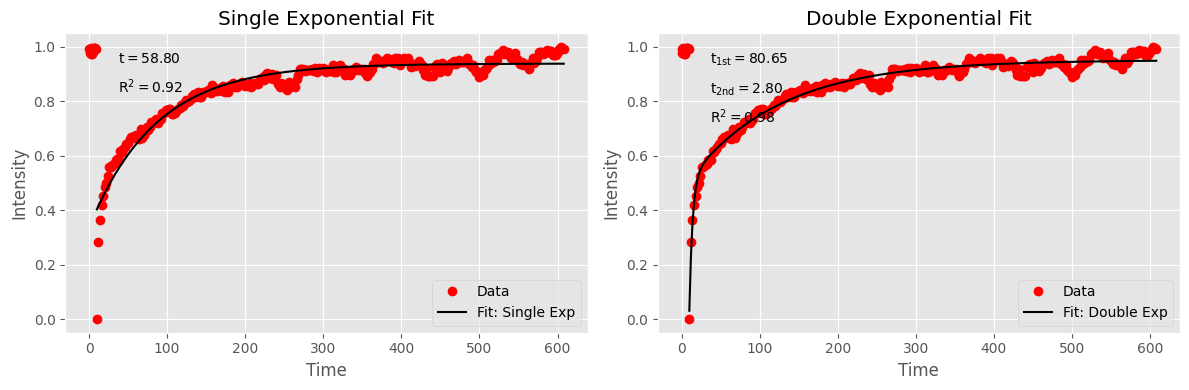

  Results - Single exp t½: 58.80, R²: 0.923
           Double exp t½1: 80.65, t½2: 2.80, R²: 0.975
--------------------------------------------------
Processing cell: results_FRAP_20250828 pRS056_050 FRAP_14 (subfolder: results_FRAP_20250828 pRS056_050 FRAP, image: FRAP 015) with 310 frames


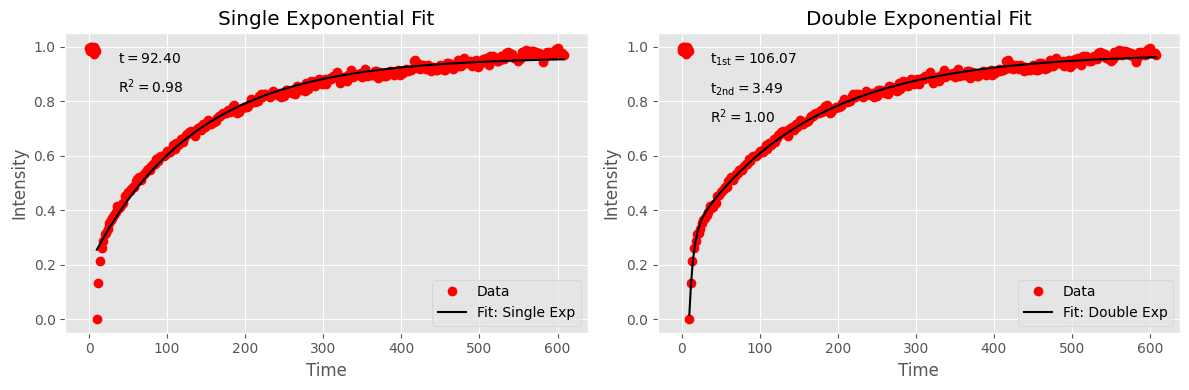

  Results - Single exp t½: 92.40, R²: 0.984
           Double exp t½1: 106.07, t½2: 3.49, R²: 0.995
--------------------------------------------------
Processing cell: results_FRAP_20250828 pRS056_050 FRAP_15 (subfolder: results_FRAP_20250828 pRS056_050 FRAP, image: FRAP 016) with 310 frames


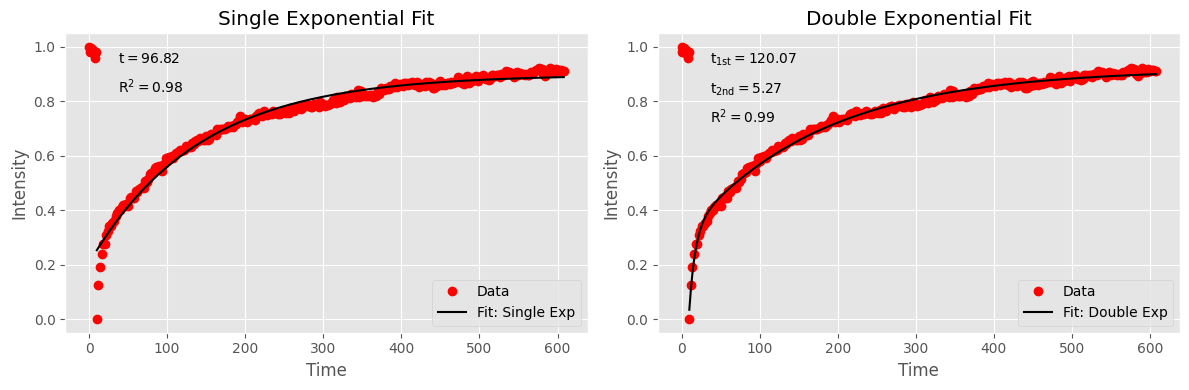

  Results - Single exp t½: 96.82, R²: 0.978
           Double exp t½1: 120.07, t½2: 5.27, R²: 0.993
--------------------------------------------------
Processing cell: results_FRAP_20250828 pRS056_050 FRAP_16 (subfolder: results_FRAP_20250828 pRS056_050 FRAP, image: FRAP 017) with 310 frames


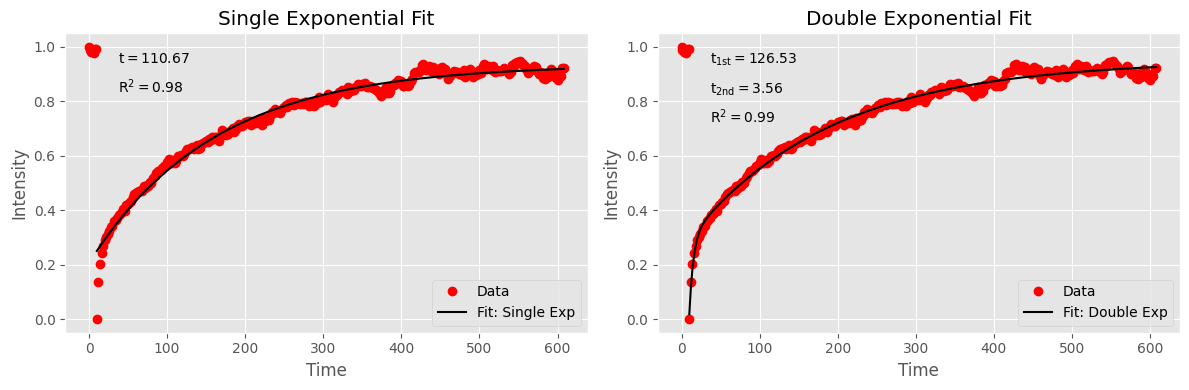

  Results - Single exp t½: 110.67, R²: 0.981
           Double exp t½1: 126.53, t½2: 3.56, R²: 0.992
--------------------------------------------------
Processing cell: results_FRAP_20250828 pRS056_050 FRAP_17 (subfolder: results_FRAP_20250828 pRS056_050 FRAP, image: FRAP 018) with 310 frames


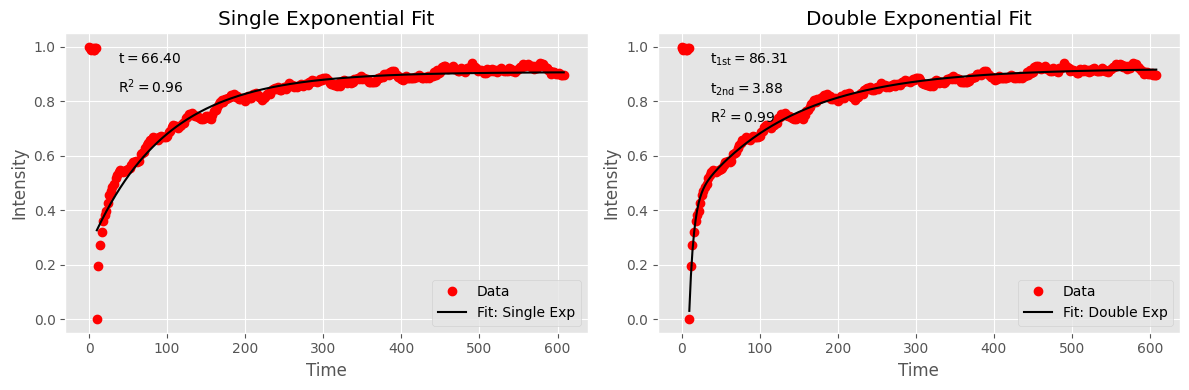

  Results - Single exp t½: 66.40, R²: 0.959
           Double exp t½1: 86.31, t½2: 3.88, R²: 0.992
--------------------------------------------------
Processing cell: results_FRAP_20250828 pRS056_050 FRAP_18 (subfolder: results_FRAP_20250828 pRS056_050 FRAP, image: FRAP 019) with 310 frames


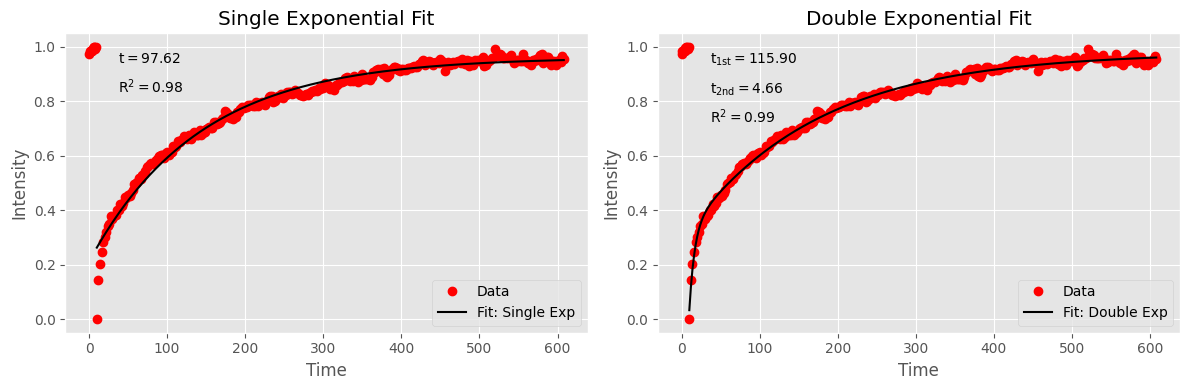

  Results - Single exp t½: 97.62, R²: 0.981
           Double exp t½1: 115.90, t½2: 4.66, R²: 0.995
--------------------------------------------------
Processing cell: results_FRAP_20250828 pRS056_050 FRAP_19 (subfolder: results_FRAP_20250828 pRS056_050 FRAP, image: FRAP 020) with 310 frames


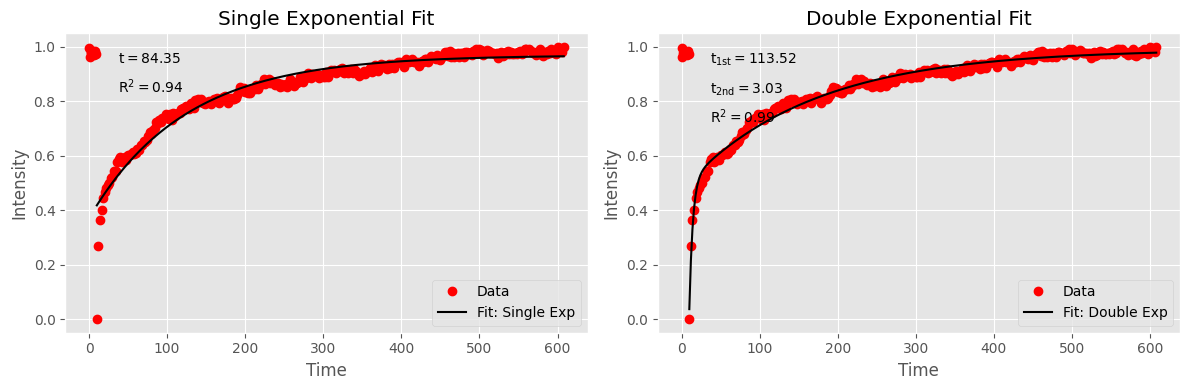

  Results - Single exp t½: 84.35, R²: 0.942
           Double exp t½1: 113.52, t½2: 3.03, R²: 0.986
--------------------------------------------------

SUMMARY
Total cells processed: 62

Cells per dataset:
dataset_type
uv    32
sf    30
Name: count, dtype: int64


In [30]:
# Process both datasets
all_fit_results = []

for dataset_type in datasets_to_process:
    print(f"\n{'='*50}")
    print(f"Processing dataset: {dataset_type}")
    print(f"{'='*50}")
    
    df_sel = combined_df[combined_df['dataset_type'] == dataset_type]
    # Get unique combinations of subfolder_id and image_name to avoid mixing data from different experiments
    unique_cells = df_sel[['subfolder_id', 'image_name', 'cell_id']].drop_duplicates()
    print(f"Found {len(unique_cells)} unique cells in '{dataset_type}' dataset")

    # iterate for each unique cell (combination of subfolder_id and image_name)
    for _, row in unique_cells.iterrows():
        subfolder_id = row['subfolder_id']
        image_name = row['image_name']
        cell_id = row['cell_id']
        
        # Filter by both subfolder_id and image_name to get data for this specific cell
        df_image = df_sel[(df_sel['subfolder_id'] == subfolder_id) & (df_sel['image_name'] == image_name)]
        print(f"Processing cell: {cell_id} (subfolder: {subfolder_id}, image: {image_name}) with {len(df_image)} frames")
        
        try:
            # Fit FRAP model
            t_half_single, t_half_double_1st_process, t_half_double_2nd_process, r_squared_single, r_squared_double = fit_model_to_frap(
                time=df_image['frame'], 
                intensity=df_image['mean_roi_frap'],
                frap_time=frap_time, 
                suptitle=None, 
                save_plot=False, 
                plot_name=None
            )
            
            print(f"  Results - Single exp t½: {t_half_single:.2f}, R²: {r_squared_single:.3f}")
            print(f"           Double exp t½1: {t_half_double_1st_process:.2f}, t½2: {t_half_double_2nd_process:.2f}, R²: {r_squared_double:.3f}")
            
        except Exception as e:
            print(f"  Error fitting cell {cell_id}: {e}")
            # Set NaN values if fitting fails
            t_half_single = t_half_double_1st_process = t_half_double_2nd_process = np.nan
            r_squared_single = r_squared_double = np.nan
        
        print("-" * 50)

        # Append results to the list
        all_fit_results.append({
            'dataset_type': dataset_type,
            'subfolder_id': subfolder_id,
            'image_name': image_name,
            'cell_id': cell_id,
            't_half_single': t_half_single,
            'r_squared_single': r_squared_single,
            't_half_double_1st_process': t_half_double_1st_process,
            't_half_double_2nd_process': t_half_double_2nd_process,
            'r_squared_double': r_squared_double
        })

# Create DataFrame from all results
df_all_fit_results = pd.DataFrame(all_fit_results)

# Display summary
print(f"\n{'='*50}")
print("SUMMARY")
print(f"{'='*50}")
print(f"Total cells processed: {len(df_all_fit_results)}")
print("\nCells per dataset:")
print(df_all_fit_results['dataset_type'].value_counts())


In [31]:
# Group by dataset_type and count unique cell_id values
cell_counts = combined_df.groupby('dataset_type')['cell_id'].nunique()
# Print the total number of processed cells for each dataset type
for dataset_type, count in cell_counts.items():
    print(f"{dataset_type}: {count} cells processed")

sf: 30 cells processed
uv: 32 cells processed


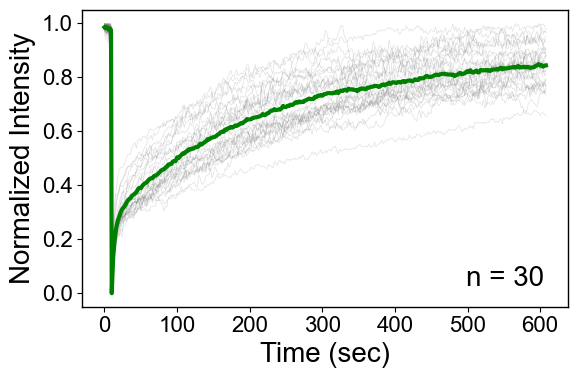

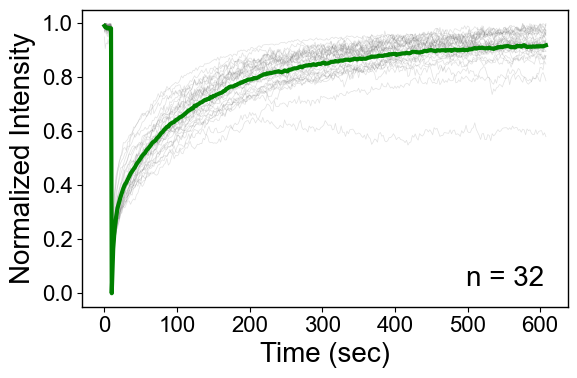

In [32]:
if process_single_days:
    plot_FRAP_trajectories(df_list=combined_df, selected_dataset='sf_d1', results_folder=results_folder)
    plot_FRAP_trajectories(df_list=combined_df, selected_dataset='sf_d2', results_folder=results_folder)
    plot_FRAP_trajectories(df_list=combined_df, selected_dataset='uv_d1', results_folder=results_folder)
    plot_FRAP_trajectories(df_list=combined_df, selected_dataset='uv_d2', results_folder=results_folder)
else:
    plot_FRAP_trajectories(df_list=combined_df, selected_dataset='sf', results_folder=results_folder)
    plot_FRAP_trajectories(df_list=combined_df, selected_dataset='uv', results_folder=results_folder)
    

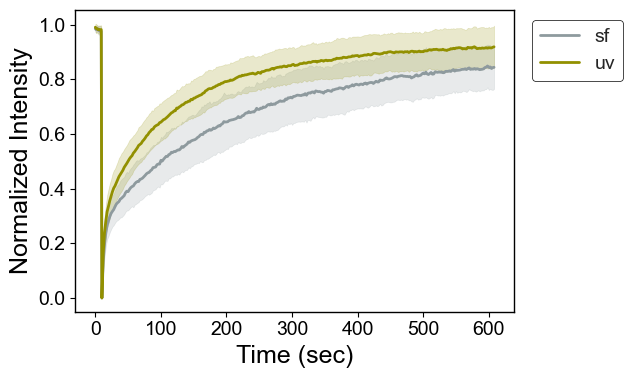

<Axes: xlabel='Time (sec)', ylabel='Normalized Intensity'>

In [40]:
plot_mean_trajectories_all(combined_df, 
                            #['sf', 'uv'],
                            list_datasets,
                            selected_field='mean_roi_frap',
                            apply_quality_check=True,
                            drop_threshold=0.8,
                            apply_min_max_normalization=True,
                            # color_map = ['green' , 'darkgreen', 'black', 'grey'] ,
                            color_map = ["#8E9A9E", '#929000'] ,
                            fig_size=(7,4),
                            use_sem=False, results_folder=results_folder)

Mean and Std of final values by dataset type:
  sf: Mean = 0.8444, Std = 0.0792, n = 30 (SEM = 0.0145)
  uv: Mean = 0.9192, Std = 0.0775, n = 32 (SEM = 0.0137)
Comparison sf vs uv:
  sf: n = 30
  uv: n = 32
  p-value: 0.000110 (***)



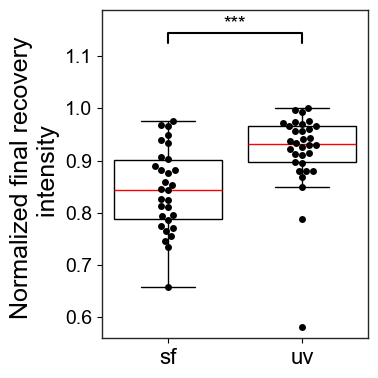

<Axes: ylabel='Normalized final recovery \n intensity'>

In [34]:
plot_box_swarm_final_values(
    df=combined_df,
    selected_field=selected_field,
    figsize=(4, 4),
    ylabel= "Normalized final recovery \n intensity",
    title="",
    y_min=0,
    #y_max=1.75,
    swarm_color="black",
    tick_size=14,
    order_categories = list_datasets, # ['sf_d1','sf_d2','uv_d1','uv_d2'],
    #order_categories = ['sf','uv'],
    show_stats=True,
    results_folder=results_folder,
)

Mean, Std, and SEM of fit results by dataset type:
  sf: Mean = 138.2452, Std = 51.6241, n = 30 (SEM = 9.4252)
  uv: Mean = 74.5824, Std = 18.9142, n = 32 (SEM = 3.3436)
Comparison sf vs uv:
  sf: n = 30
  uv: n = 32
  p-value: 0.000000 (****)



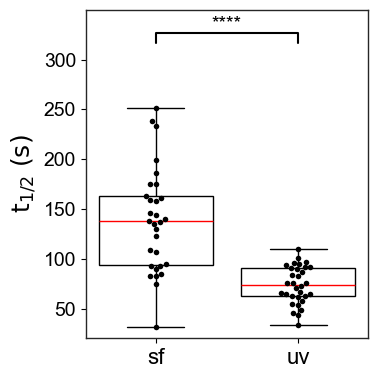

<Axes: ylabel='$t_{1/2}$ (s)'>

In [35]:
# Plot t_half_single comparison
plot_box_swarm_fit_results(
    df=df_all_fit_results,
    selected_field="t_half_single",
    figsize=(4, 4),
    ylabel=r"$t_{1/2}$ (s)",
    title="",
    y_min=0,
    order_categories =  list_datasets, # ['sf_d1','sf_d2','uv_d1','uv_d2'],
    #order_categories = ['sf','uv'],
    y_max=None,  # Let it auto-scale based on your data
    swarm_color="black",
    tick_size=14,
    show_stats=True,
    results_folder=results_folder,
)